# ___`MR-PMM` using `brms`___
---------------------

In [1]:
print(R.version$version.string)

[1] "R version 4.6.1 (2026-06-24 ucrt)"


In [2]:
# https://cran.r-project.org/web/packages/brms/vignettes/brms_phylogenetics.html

# https://benjamin-halliwell.github.io/MR-PMM/MR-PMM_tutorial.html
# https://benjamin-halliwell.github.io/MR-PMM/MR-PMM_euc_example_analysis.html

# https://paulbuerkner.com/brms/articles/index.html
# https://paulbuerkner.com/brms/articles/brms_multivariate.html
# https://paulbuerkner.com/brms/articles/brms_phylogenetics.html
# https://paulbuerkner.com/brms/reference/brmsformula.html

# https://journal.r-project.org/articles/RJ-2018-017/index.html

In [2]:
suppressPackageStartupMessages({
    library("ape")
    library("brms")
    library("readxl")
    library("geiger")
    library("ggplot2")
    library("bayesplot")
})

In [3]:
packageVersion("geiger")

[1] '2.0.11'

In [4]:
packageVersion("brms")

[1] '2.23.0'

In [6]:
#------------------------------------------------------------------
# USING THE SUBSET WITH REPEATED RECORDS SINCE brms CAN HANDLE IT
#------------------------------------------------------------------

fred4 <- read.csv("../../data/chapter2/FRED/subsets/continuous_raw.csv")
# duplicating the binominal column with another name as brms won't allow the same variable to be duplicated as random effects (phylogenetic and non phylogenetic)
fred4$taxa <- fred4$binominal

# mycorrhizal state column
states <- readxl::read_xlsx(path = "../../data/chapter2/FRED/subsets/final.xlsx", sheet = "final")[, c("binominal", "state")] # dataset approved by Luke
states$binominal <- gsub(states$binominal, pattern = ' ', replacement = '_') # the binominal mnames column in this file has spaces instead of underscores

fred4 <- merge(x = fred4, y = states, by = "binominal", all.x = TRUE) # merge the mycorrhizal states column

# log and mean scale the continuous traits
fred4$F00679 <- scale(log(fred4$F00679))[, 1]
fred4$F00727 <- scale(log(fred4$F00727))[, 1]
fred4$F00709 <- scale(log(fred4$F00709))[, 1]

head(fred4)

,binominal,F01286,F01287,F01289,F00679,F00727,F00709,taxa,state
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,Abies_alba,Abies,alba,Pinaceae,0.1022601,0.01898775,-0.09495718,Abies_alba,EcM
2,Abies_alba,Abies,alba,Pinaceae,0.3021937,-0.50207617,0.44679293,Abies_alba,EcM
3,Abies_alba,Abies,alba,Pinaceae,0.5950494,0.99512162,-0.79519190,Abies_alba,EcM
4,Abies_nephrolepis,Abies,nephrolepis,Pinaceae,-0.2902498,0.21214483,0.14317141,Abies_nephrolepis,EcM
5,Acacia_auriculiformis,Acacia,auriculiformis,Fabaceae,-0.4679512,1.40509755,-0.03146336,Acacia_auriculiformis,EcMAM
6,Acacia_auriculiformis,Acacia,auriculiformis,Fabaceae,0.1630808,0.01069987,0.44679293,Acacia_auriculiformis,EcMAM


In [8]:
tree <- ape::read.tree("../../data/chapter2/uphylomaker/FRED4_1301.tre")
if(!ape::is.binary(tree)) tree <- ape::multi2di(tree)
stopifnot(all(tree$tip.label %in% fred4$binominal))

corrmat <- ape::vcv.phylo(phy = tree, corr = TRUE) # the issue with ape::vcv.phylo is that it uses a BM model to compute the variance covariance matrix - WE WANT TO USE AN OU PROCESS INSTEAD
# look up - https://discourse.mc-stan.org/t/rescaling-phylogenetic-tree-for-non-brownian-phylogenetic-models-in-brms/29637/4
# for this we can use rescale.phylo function from the R library geiger to transform a phylogeny into a OU phylogeny

In [31]:
ou_rescaler <- geiger:::rescale.phylo(tree, model = "OU") # to use functions that aren't exported by packages, use the triple colon syntax package:::function

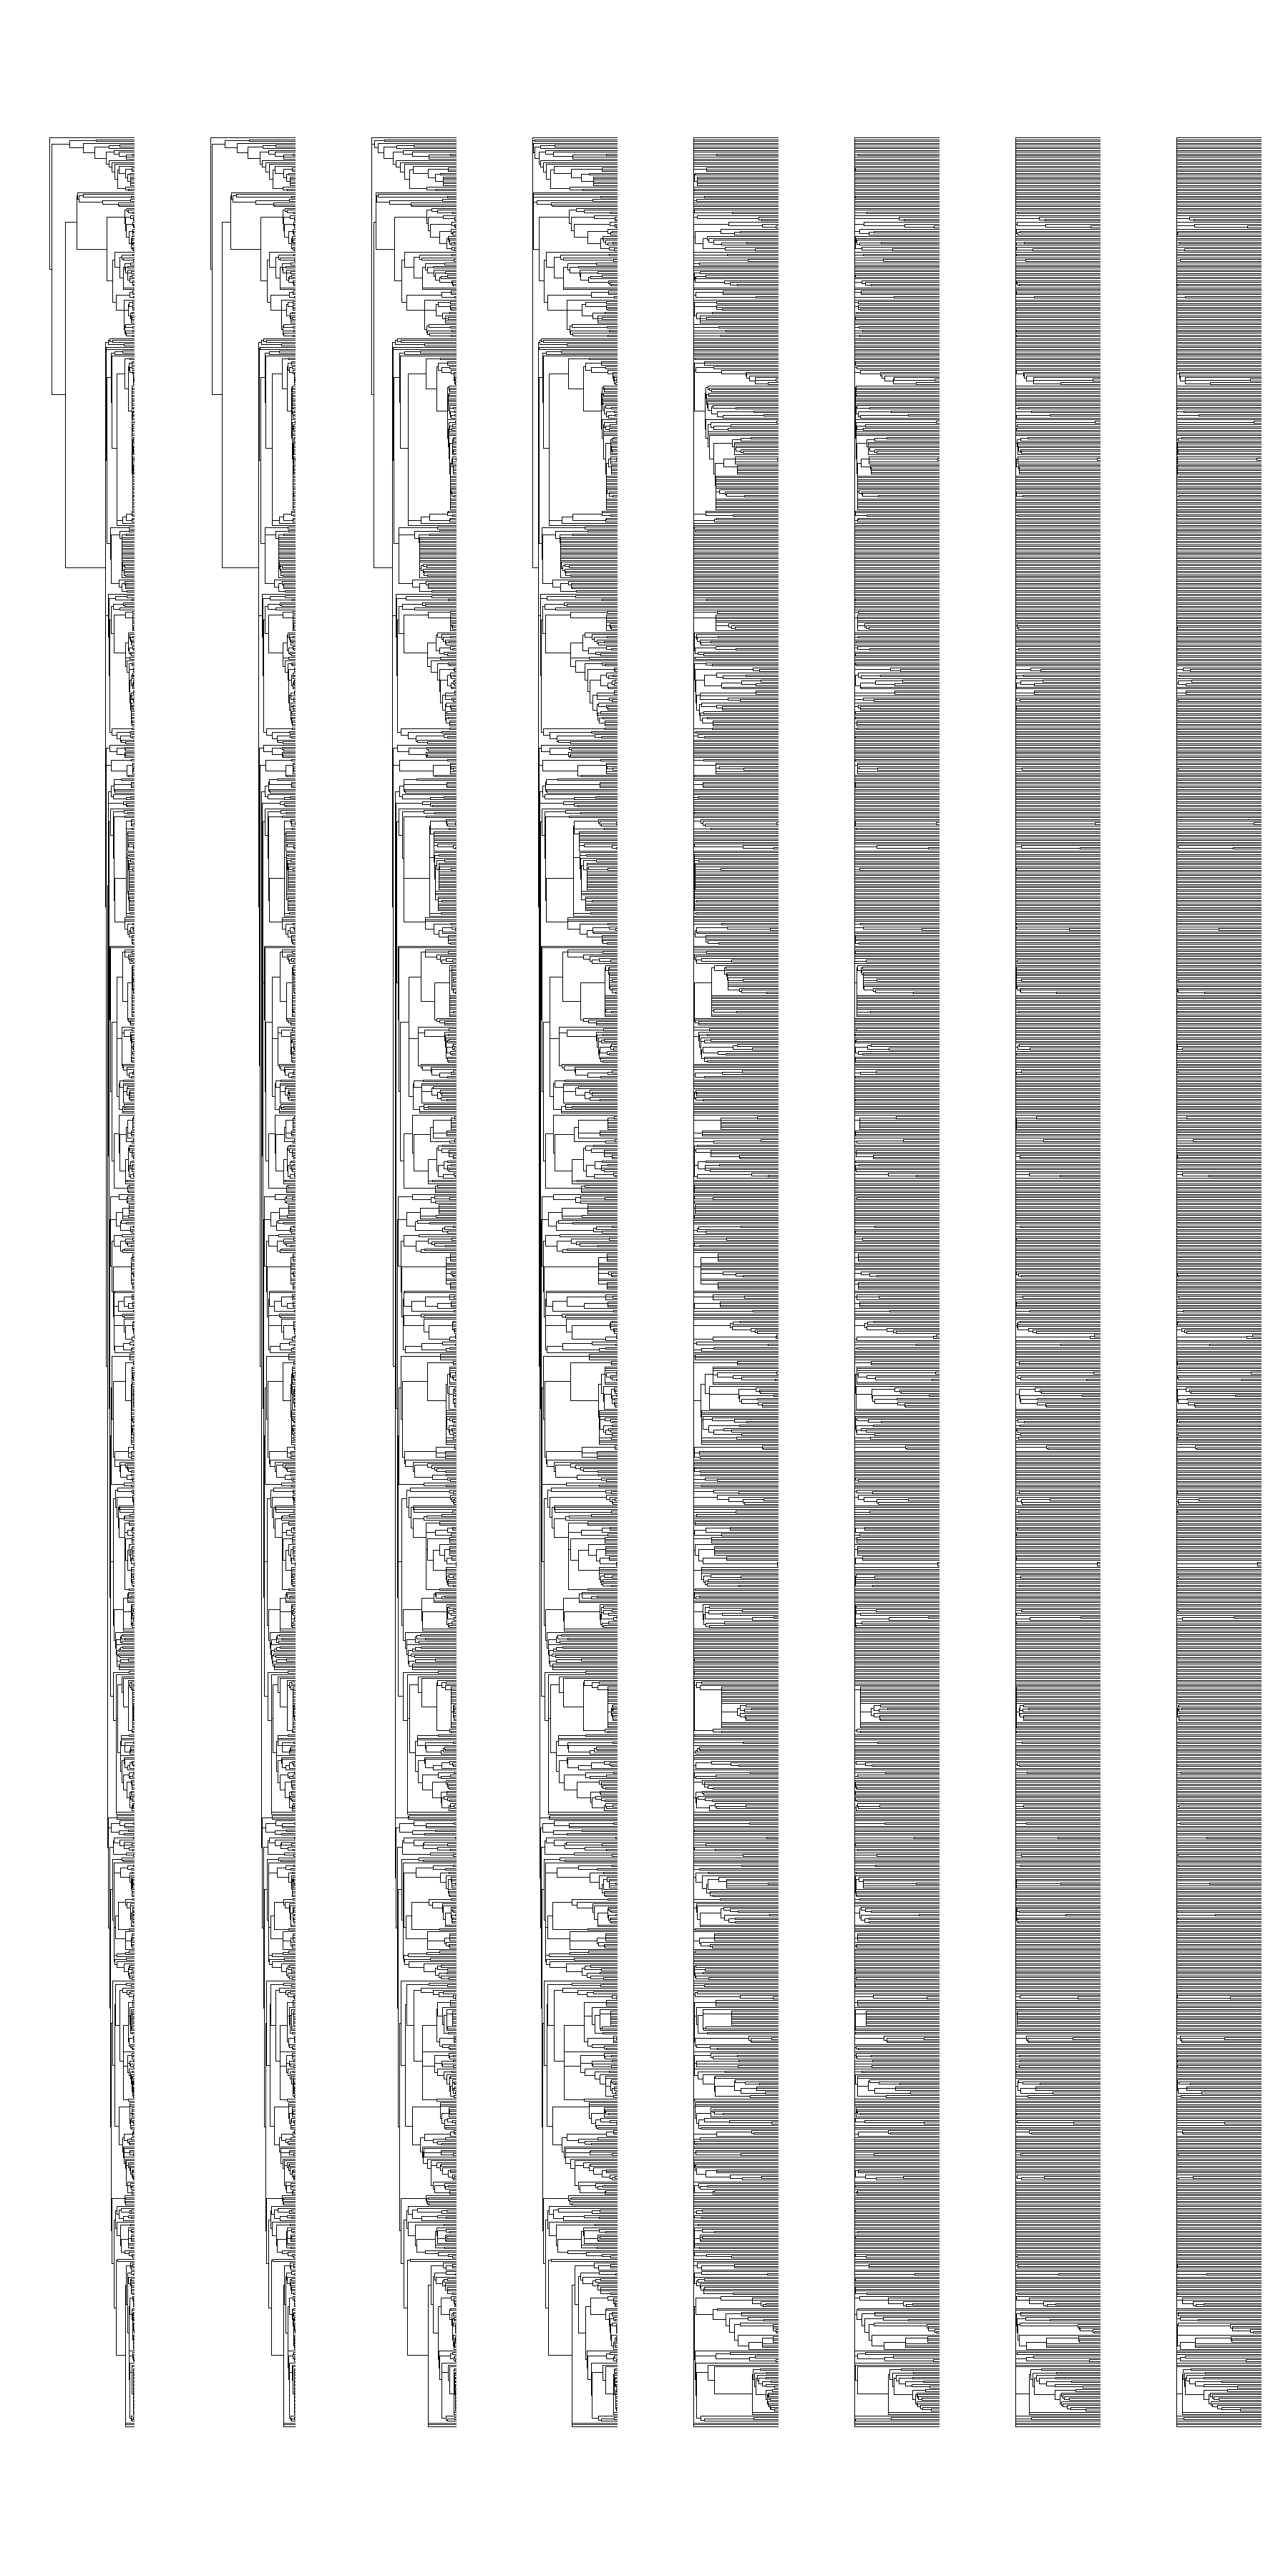

In [42]:
options(repr.plot.width = 15, repr.plot.height = 30)

par(mfrow = c(1, 8))

plot(tree, show.tip.label = FALSE)
plot(ou_rescaler(alpha = 0.001), show.tip.label = FALSE)
plot(ou_rescaler(alpha = 0.005), show.tip.label = FALSE)
plot(ou_rescaler(alpha = 0.01), show.tip.label = FALSE)
plot(ou_rescaler(alpha = 0.10), show.tip.label = FALSE)
plot(ou_rescaler(alpha = 0.25), show.tip.label = FALSE)
plot(ou_rescaler(alpha = 0.50), show.tip.label = FALSE)
plot(ou_rescaler(alpha = 0.75), show.tip.label = FALSE)

In [9]:
# mvbind() is used to bind multivariate response variables in brms

# https://paulbuerkner.com/brms/articles/brms_multivariate.html
# if we were to include a categorical trait that has repetitions and we want the model to factor in the within group correlations in that trait across all the response variables,
# we specify that trait the following way 
# (1|p|trait) - here p is just an arbitrary choice - this template means - fit a random intercept over "trait" and consider within group correlations in that trait across all the response variables
# we can choose any alphabet or a number of our liking instead of p in the above formula
# HOWEVER, ONCE SPECIFIED, REUSE OF THAT SYMBOL AGAIN e.g. (1+x|i|g) and (1+z|i|g) WILL LEAD TO CORRELATIONS BEING COMPUTED BETWEEN THE TWO DIFFERENT INSTANCES OF THE GROUP EFFECT i

In [ ]:
# thread on mc-stan discourse regarding model specification
# https://discourse.mc-stan.org/t/multilevel-multiresponse-phylogenetic-mixed-models-with-brms/41411

model_0 <- brms::brm(brms::brmsformula(mvbind(F00727, F00679, F00709) ~ state + (1|p|gr(binominal, cov = corrmat)) + (1|q|taxa)) + set_rescor(TRUE), # state is our predictor (fixed effect)
                   # (1|p|gr(binominal, cov = corrmat)) specifies that the relationships between the `binominal` are to be inferred from the covariance matrix `cov`
                   # and the effects are considred correlated across the response variables - |p|
                   # our fourmula includes two random effects
                   # (1|p|gr(binominal, cov = corrmat)) will capture phylogenetic between species trait correlation while (1|q|taxa) will capture the non-phylogenetic between species trait correlation
                   # (1|q|taxa) is a basic multilevel model with a varying intercept over species (taxa) - with cross response correlations allowed
                   # in (1|p|gr(binominal, cov = corrmat)), by using cov = corrmat in the gr function, we make sure that species are correlated as specified by the covariance matrix corrmat. 
                   data = fred4,
                   data2 = list(corrmat = corrmat), # data2 argument is to pass extra data that does not conform to the formulae's format
                   chains = 6, # each chain will be run in a separate process
                   cores = 6, # set this to the number of chains
                   threads = 4, # within chain (process) parallelization
                   iter = 10000)

# rescor - residual correlation - indicates if residual correlation between the response variables should be modeled.
# currently this is only possible in multivariate gaussian and student models and only relevant in multivariate models

# saveRDS(object = model_0, file = "../../data/chapter2/rdata/brms_model_0.Rds")

In [ ]:
# control = list(max_treedepth = 15) - this is how you ovveride the default max_treedepth parameter
# https://discourse.mc-stan.org/t/how-many-chains-i-need-for-my-model/8511

In [ ]:
model_1 <- brms::brm(brms::brmsformula(mvbind(F00727, F00679, F00709) ~ state + (1|p|taxa)) + set_rescor(TRUE), # a model with no phylogegentic random effects
                        data = fred4, data2 = list(corrmat = corrmat), chains = 6, cores = 6, threads = 4, iter = 10000)

# saveRDS(object = model_1, file = "../../data/chapter2/rdata/brms_model_1.Rds")

In [ ]:
# reporting brms model results in a manuscript
#-----------------------------------------------

# https://www.sciencedirect.com/science/article/pii/S037811272600397X?pes=vor&utm_source=clarivate&getft_integrator=clarivate
# https://www.nature.com/articles/s41559-025-02945-8
# https://www.sciencedirect.com/science/article/pii/S2351989426002398
# https://www.sciencedirect.com/science/article/pii/S0039606026003156
# https://www.science.org/doi/epdf/10.1126/science.adl6282?src=getftr&utm_source=clarivate&getft_integrator=clarivate

# ___Analyses___
-------------------

In [6]:
correlated_taxa <- readRDS("../../data/chapter2/rdata/hie-general/brms_model_1.Rds") # (F00727, F00679, F00709) ~ state + (1 | q | taxa)

In [7]:
summary(correlated_taxa)

 Family: MV(gaussian, gaussian, gaussian) 
  Links: mu = identity
         mu = identity
         mu = identity 
Formula: F00727 ~ state + (1 | q | taxa) 
         F00679 ~ state + (1 | q | taxa) 
         F00709 ~ state + (1 | q | taxa) 
   Data: fred4 (Number of observations: 5218) 
  Draws: 4 chains, each with iter = 10000; warmup = 5000; thin = 1;
         total post-warmup draws = 20000

Multilevel Hyperparameters:
~taxa (Number of levels: 1301) 
                                       Estimate Est.Error l-95% CI u-95% CI
sd(F00727_Intercept)                       0.91      0.02     0.87     0.96
sd(F00679_Intercept)                       0.83      0.02     0.78     0.87
sd(F00709_Intercept)                       0.87      0.02     0.83     0.91
cor(F00727_Intercept,F00679_Intercept)    -0.78      0.02    -0.81    -0.74
cor(F00727_Intercept,F00709_Intercept)    -0.60      0.02    -0.65    -0.56
cor(F00679_Intercept,F00709_Intercept)     0.01      0.04    -0.06     0.09
            

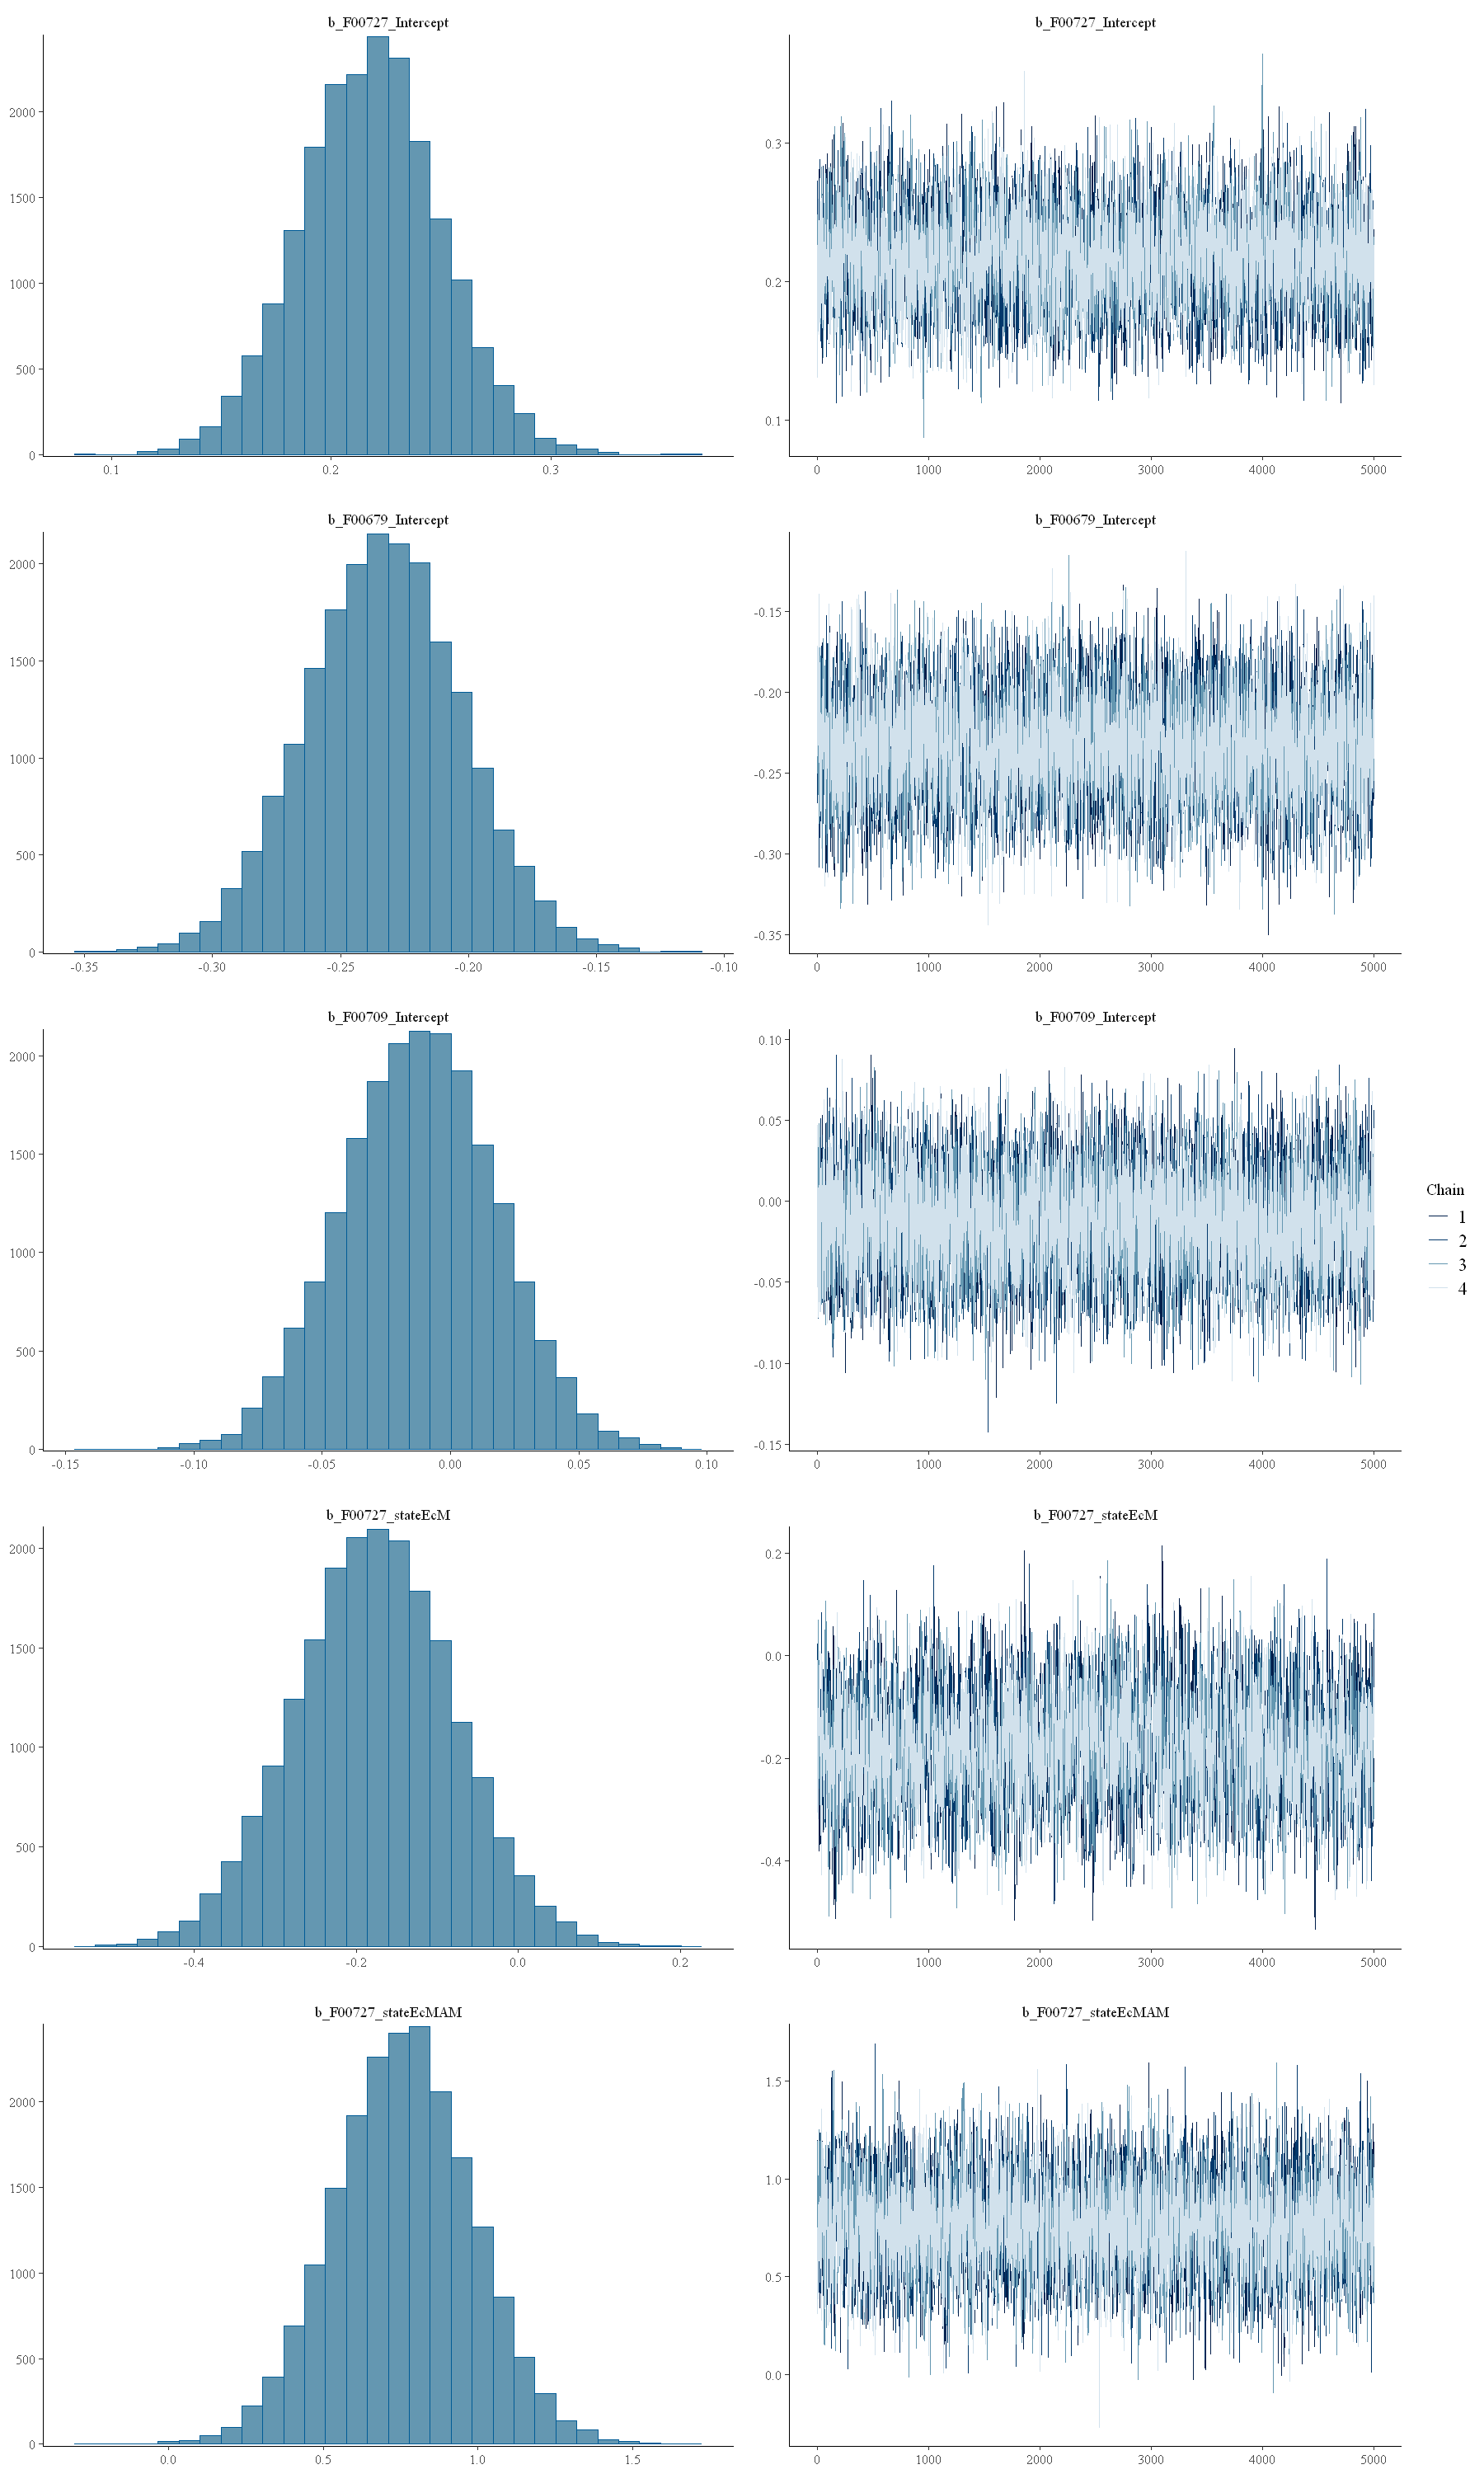

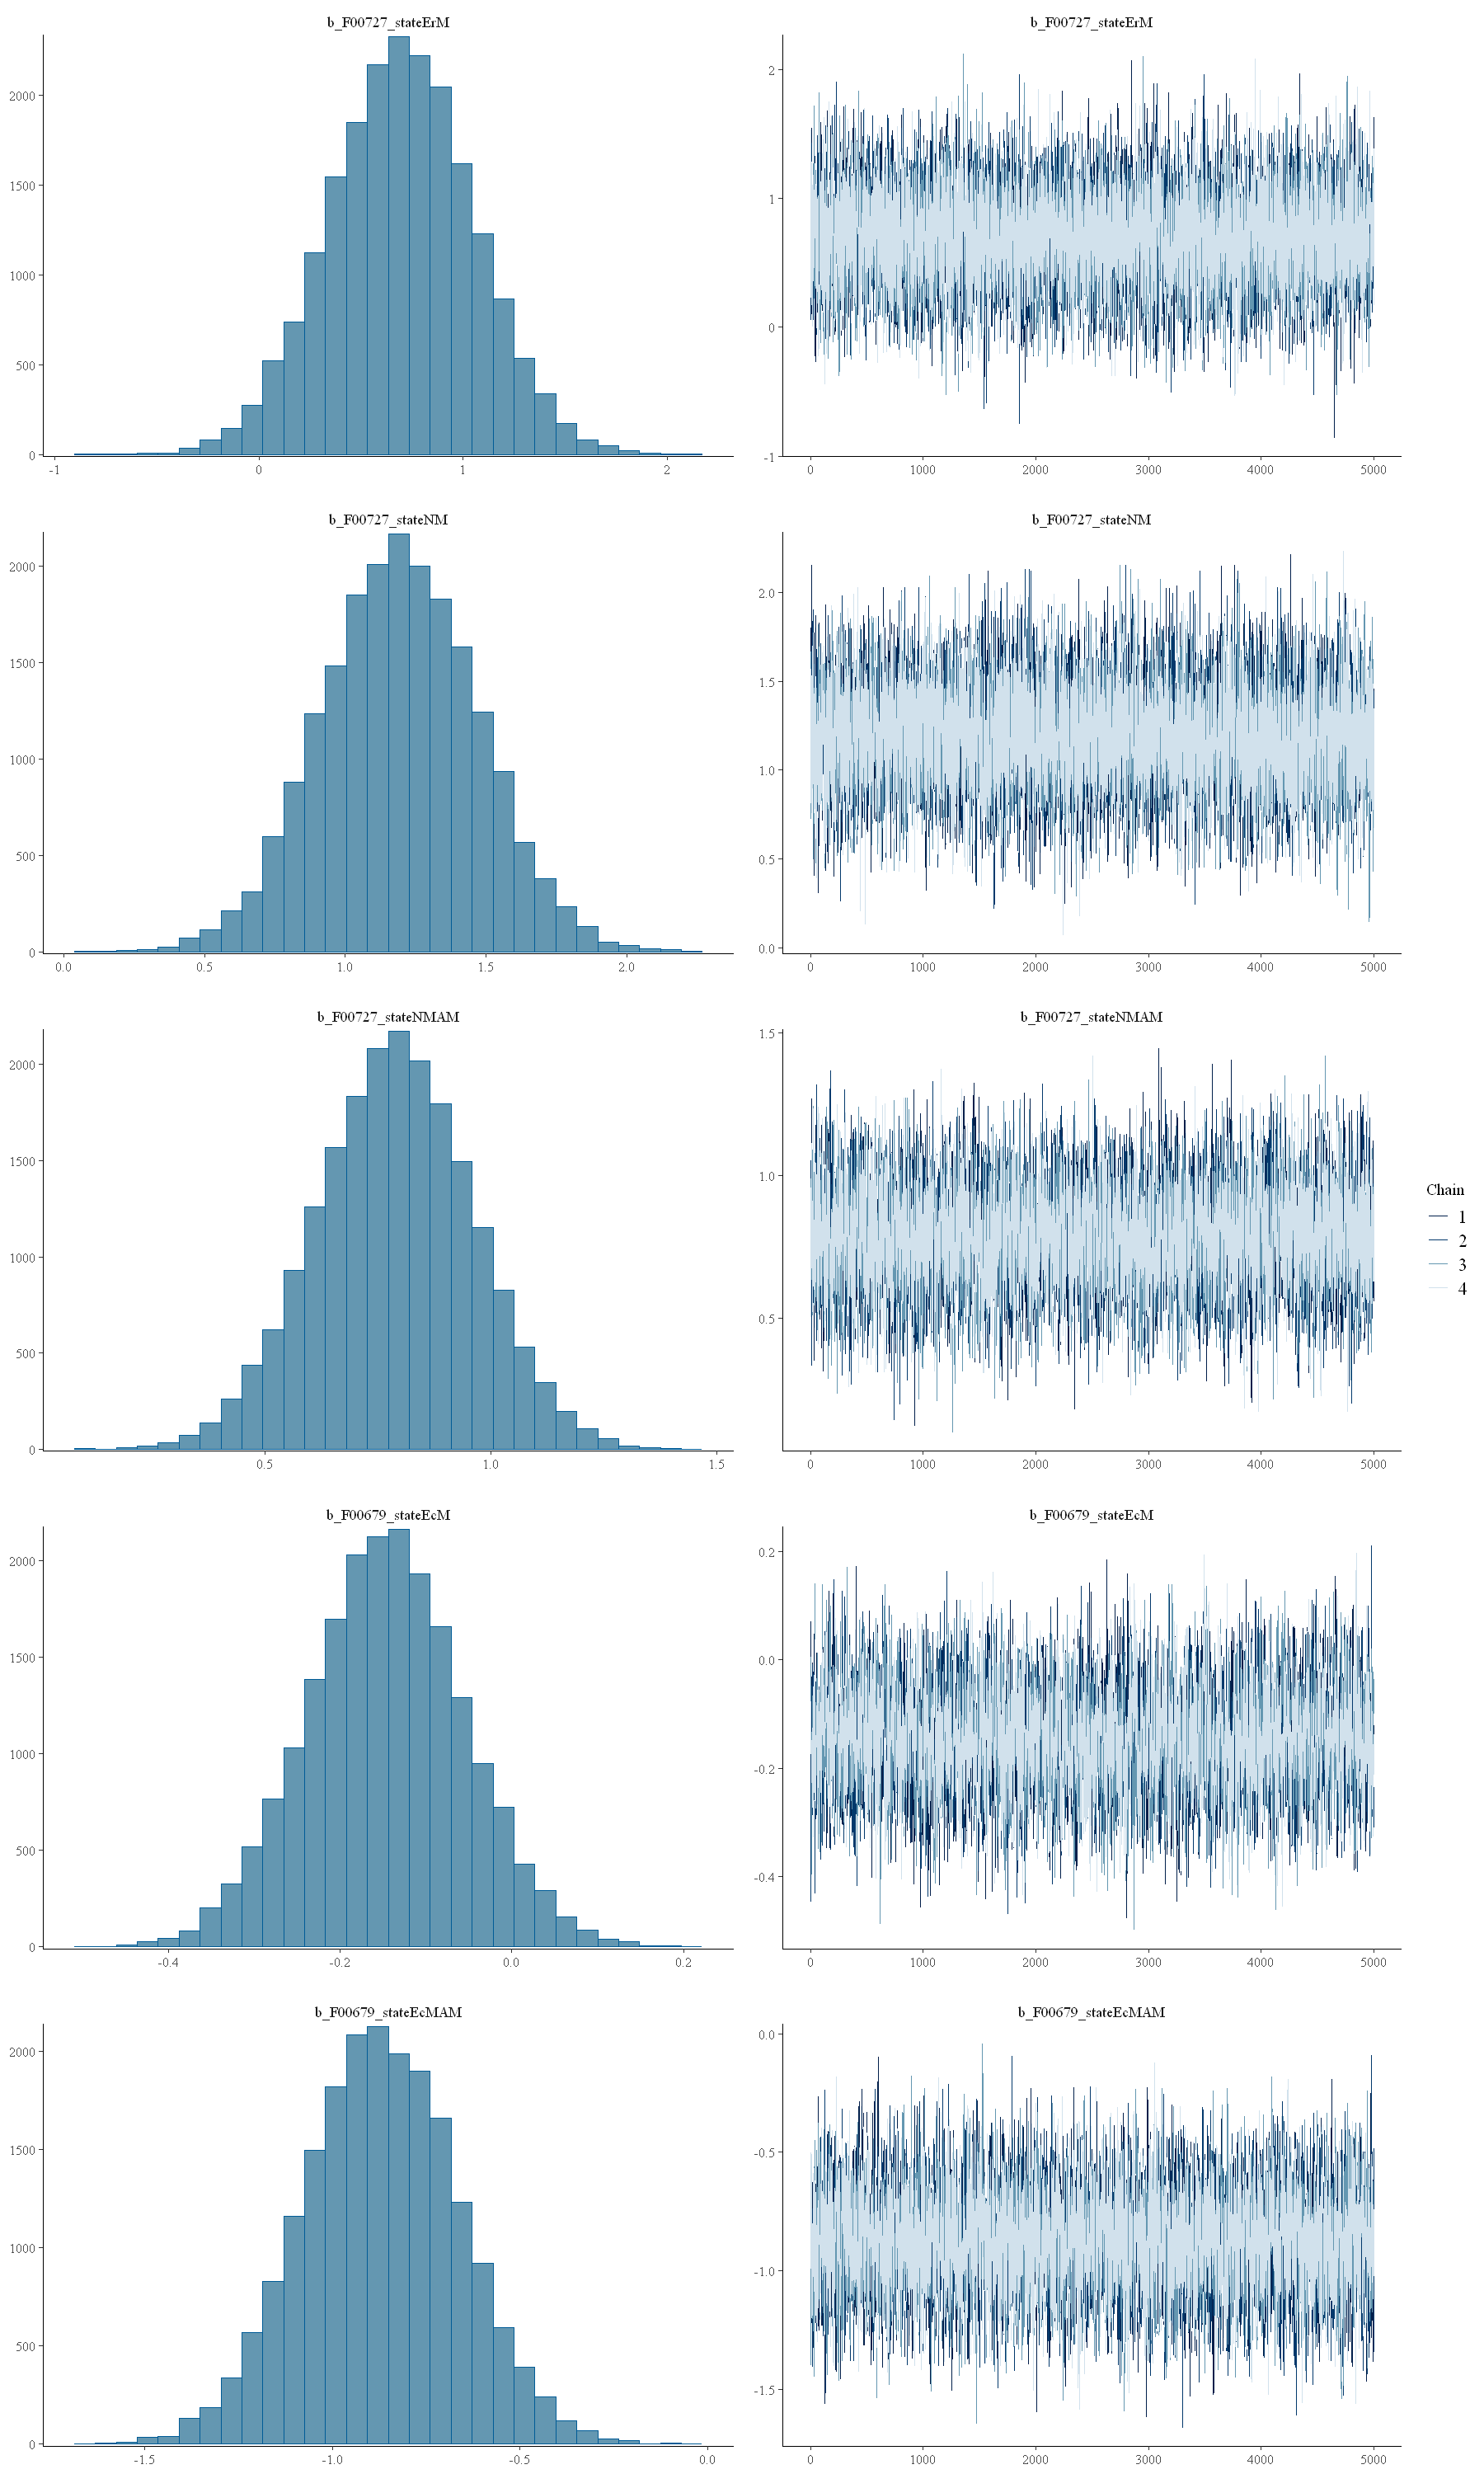

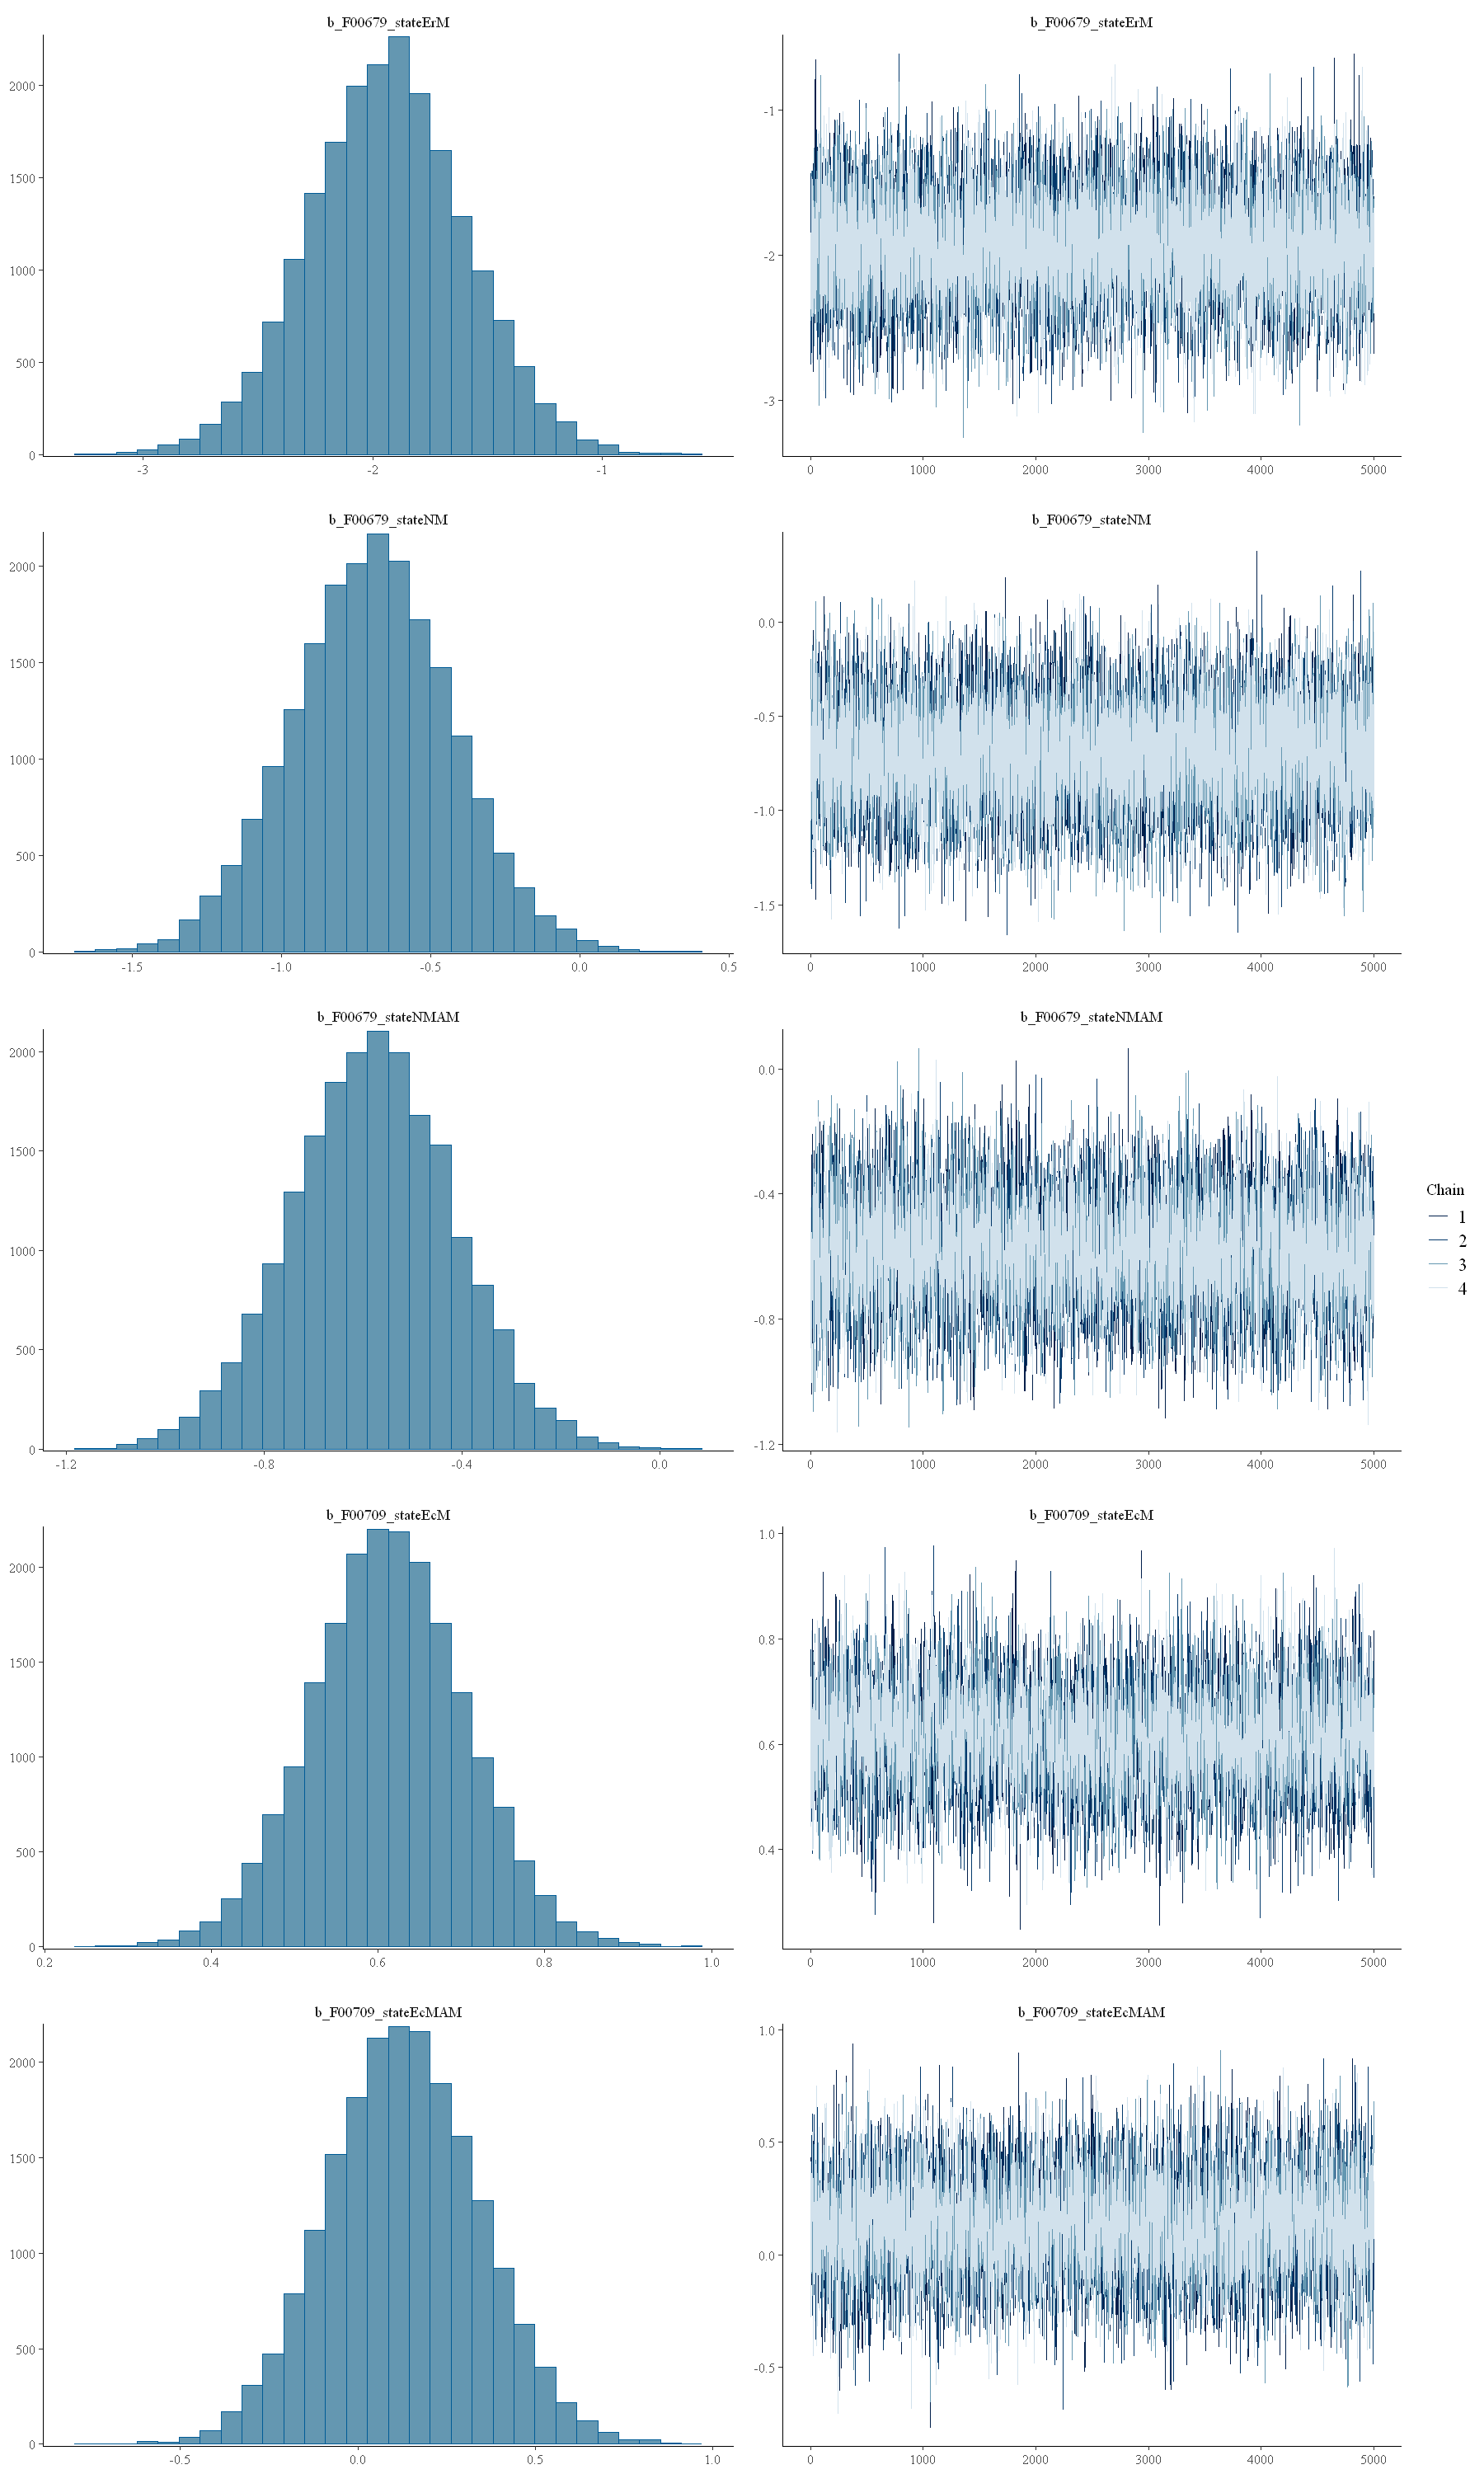

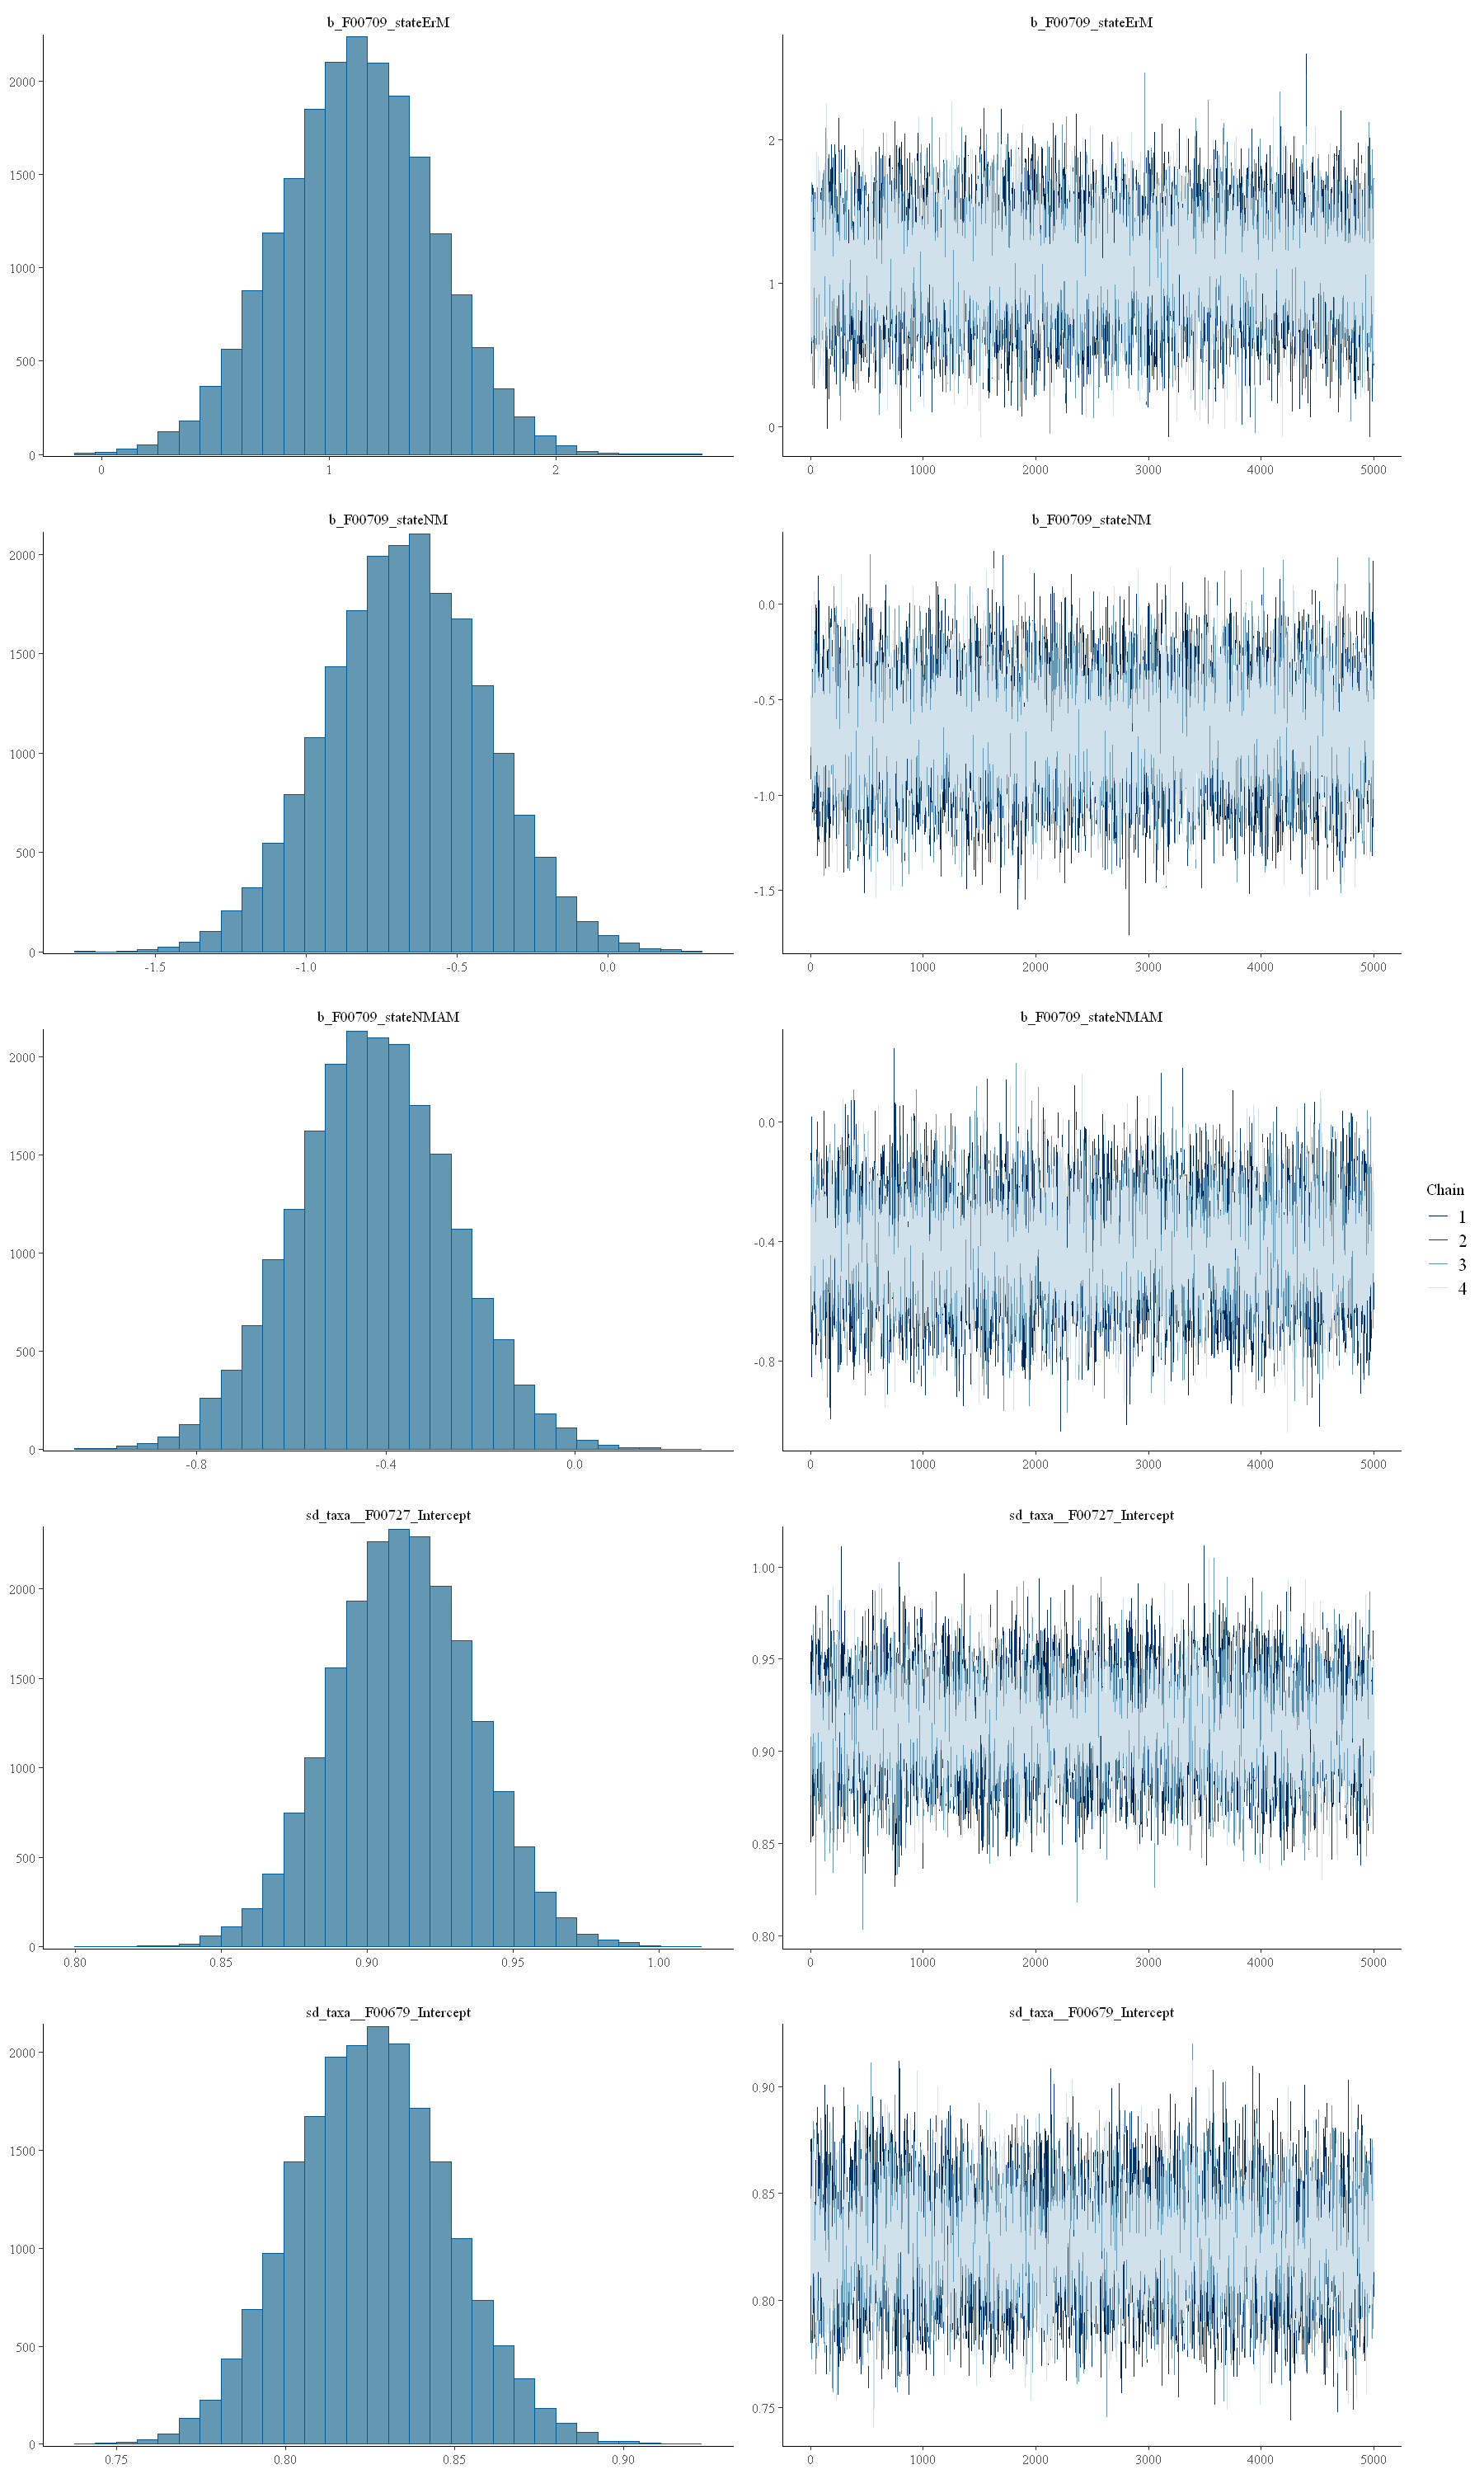

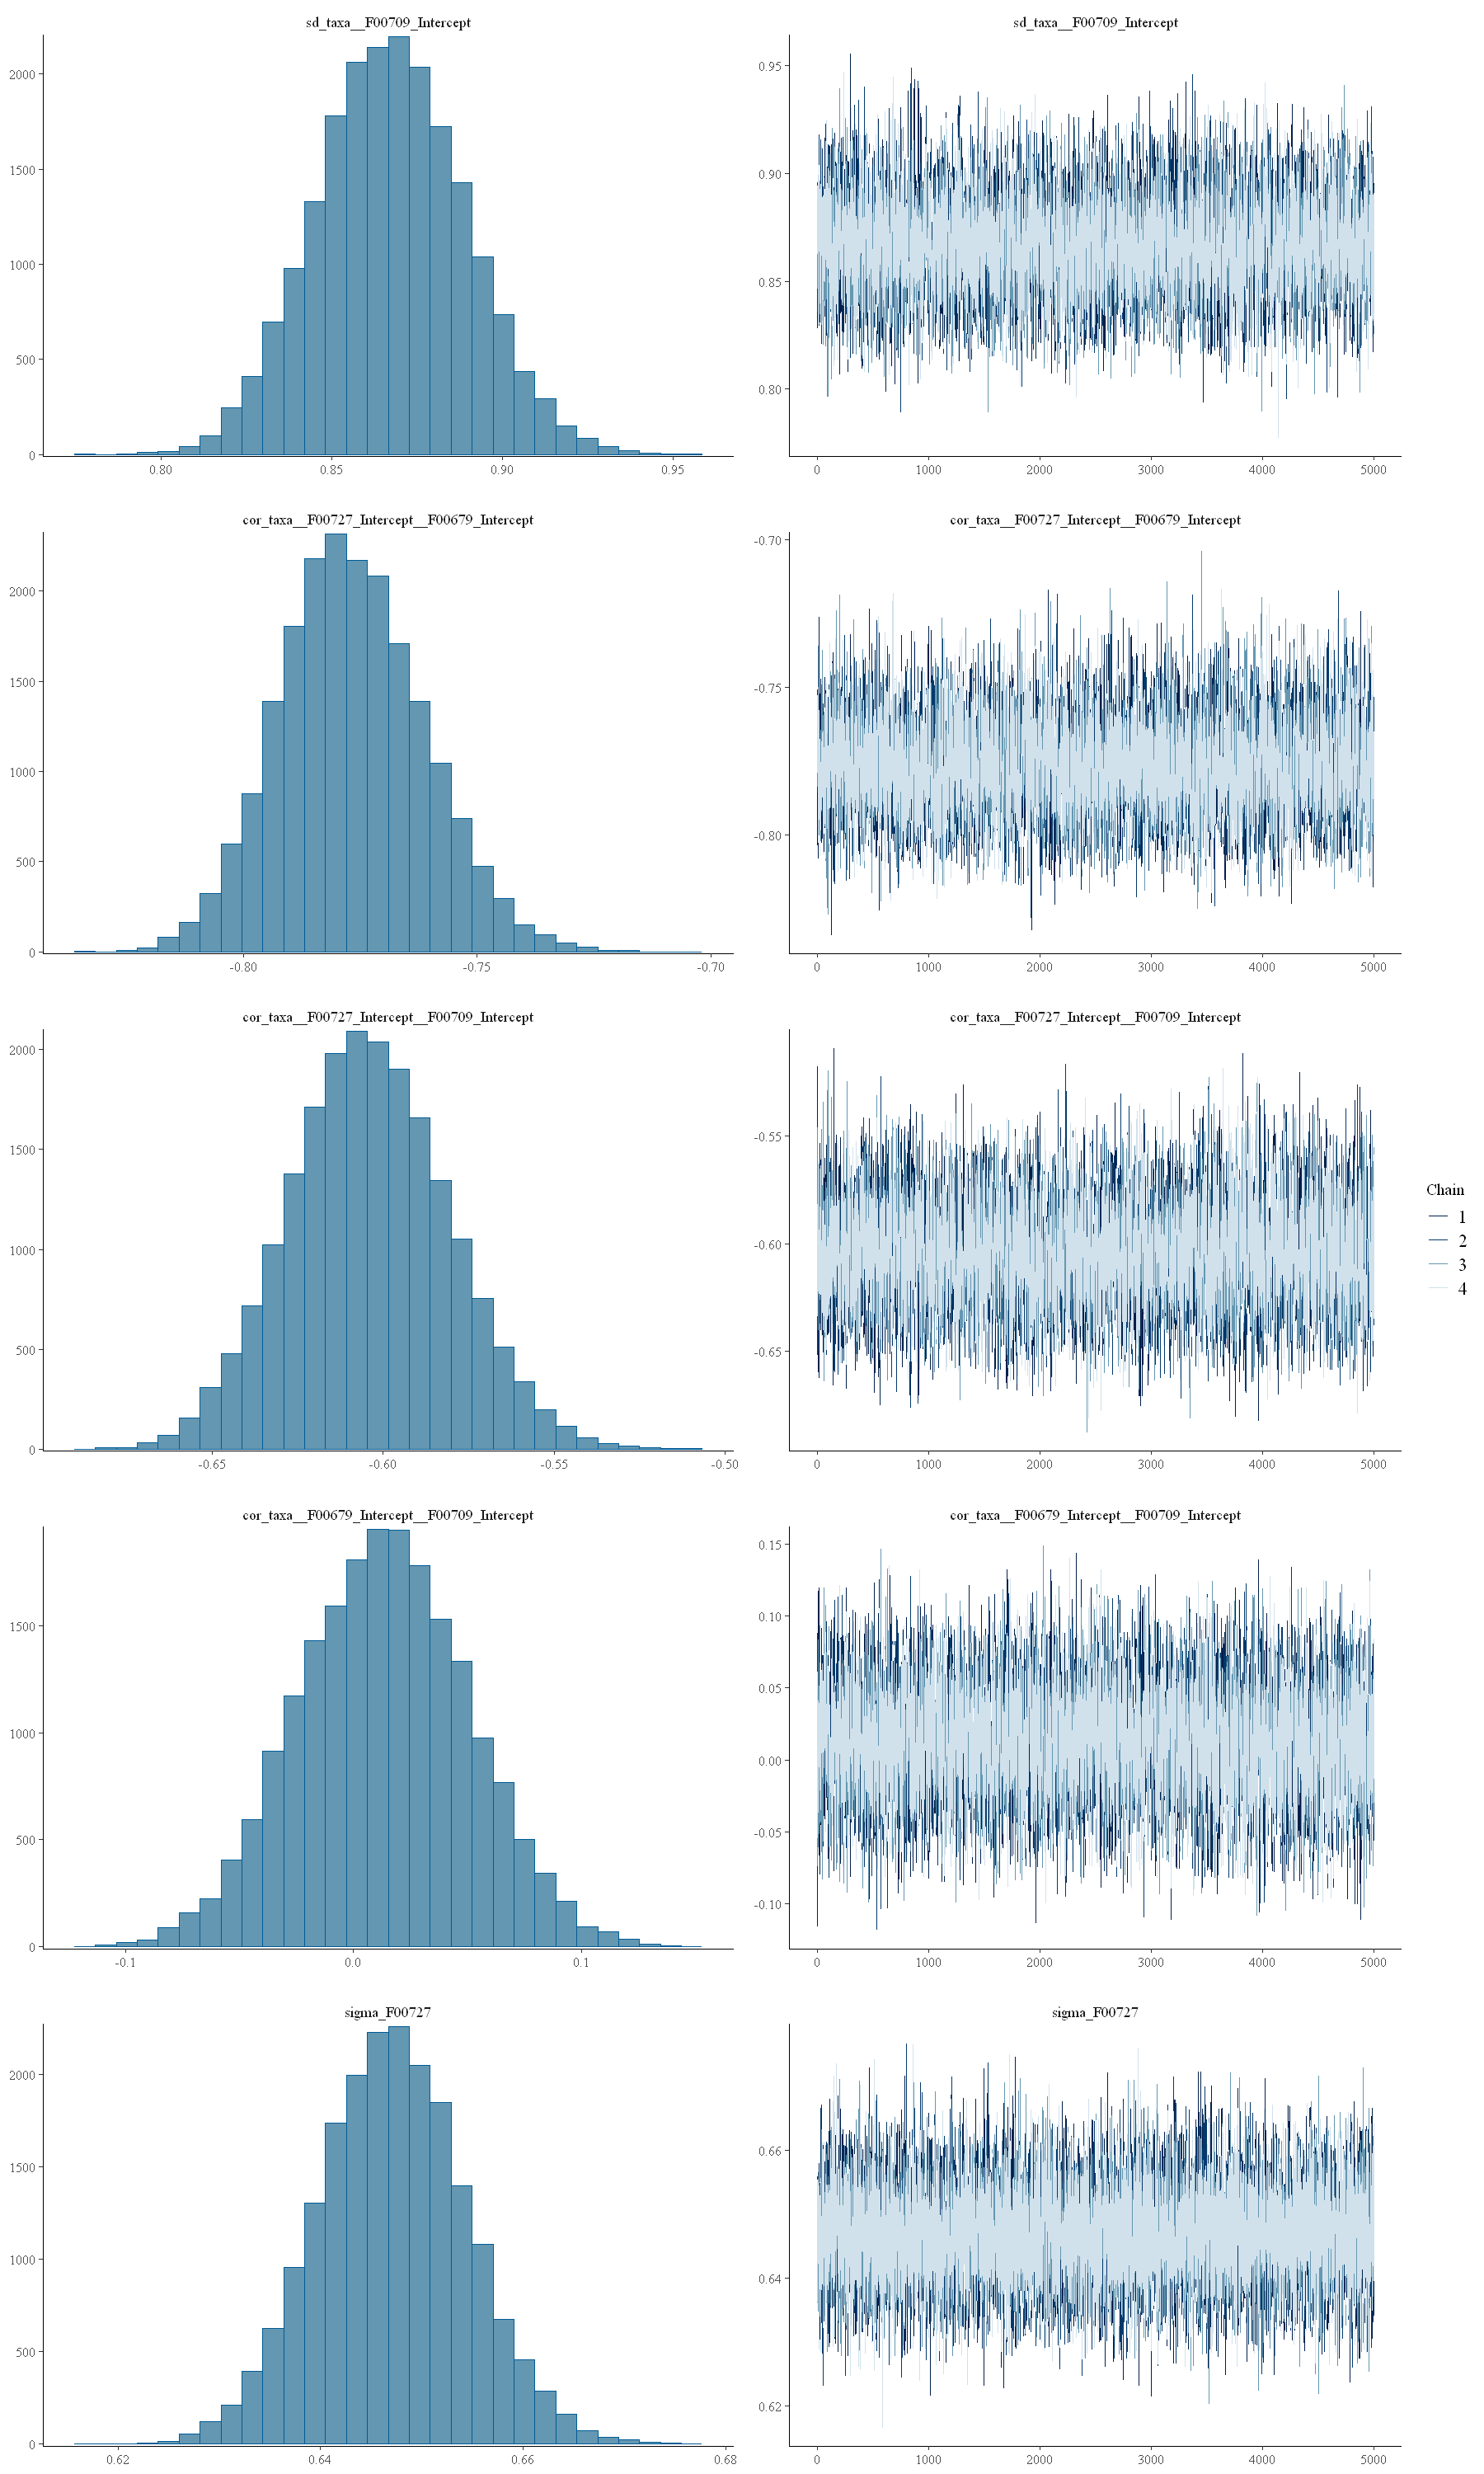

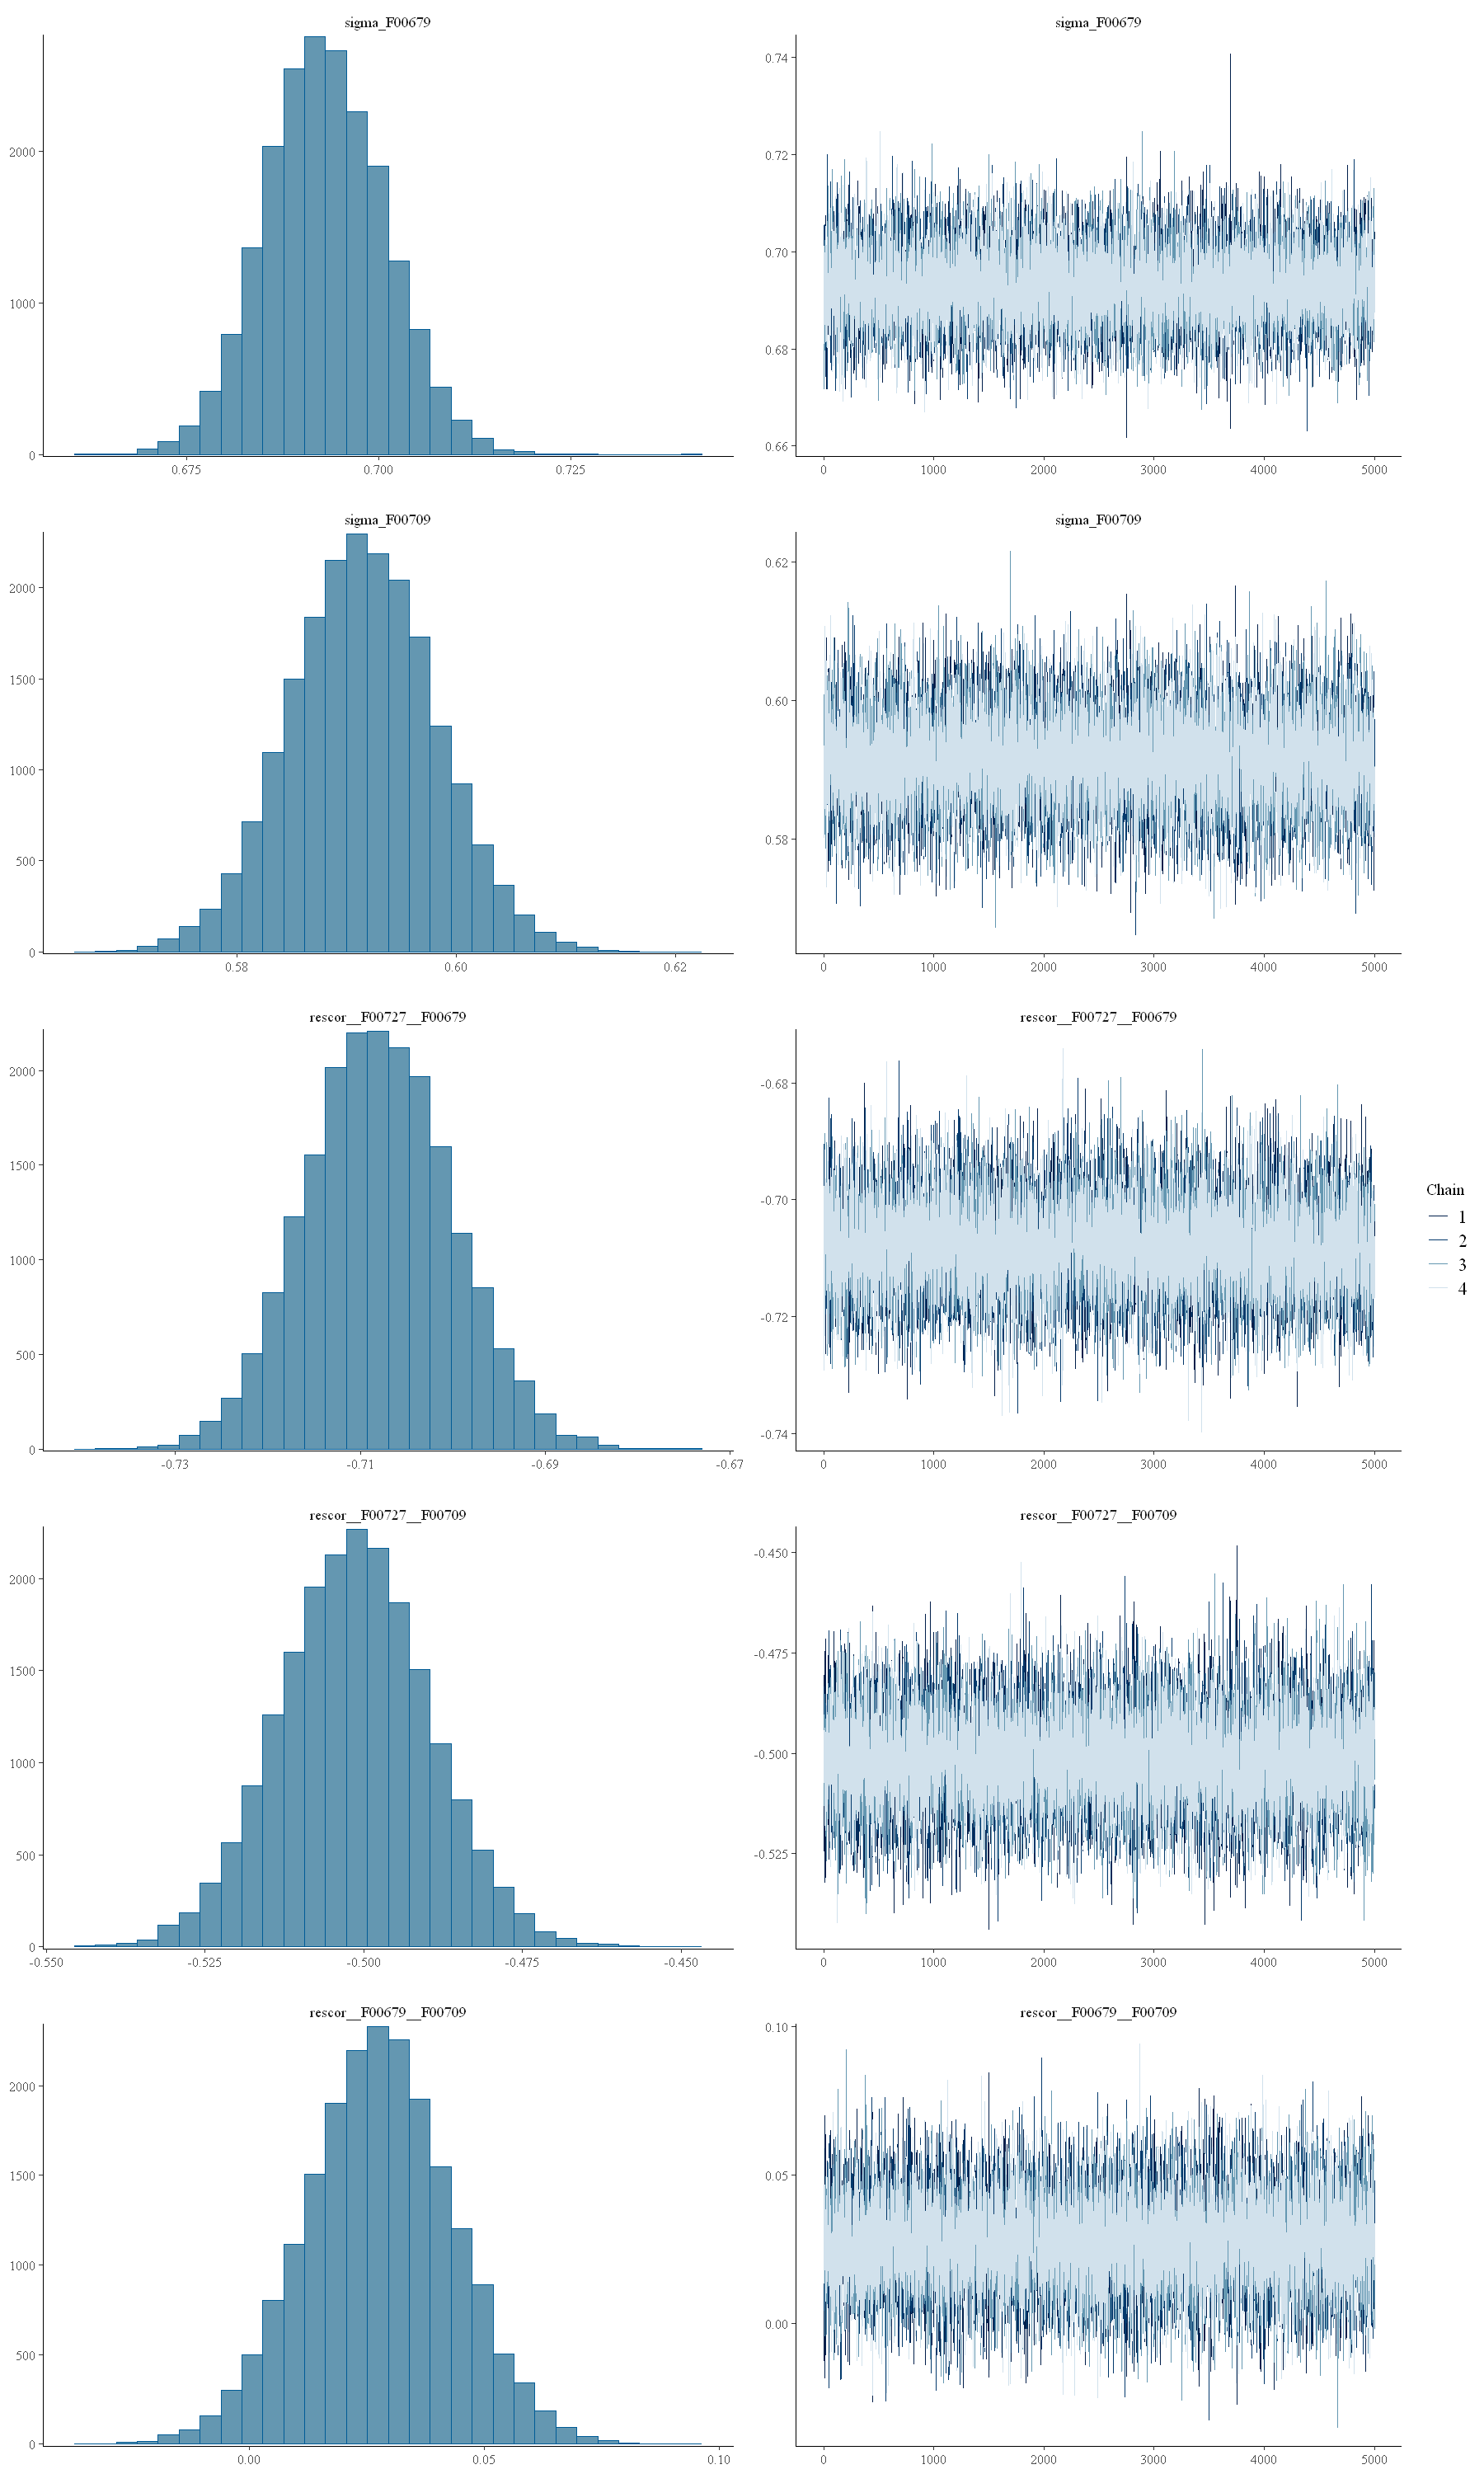

In [8]:
options(repr.plot.width = 15, repr.plot.height = 25)
plot(correlated_taxa)

Ignoring unknown labels:
• fill : "NA"
• colour : "NA"
Ignoring unknown labels:
• fill : "NA"
• colour : "NA"
Ignoring unknown labels:
• fill : "NA"
• colour : "NA"
Ignoring unknown labels:
• fill : "NA"
• colour : "NA"


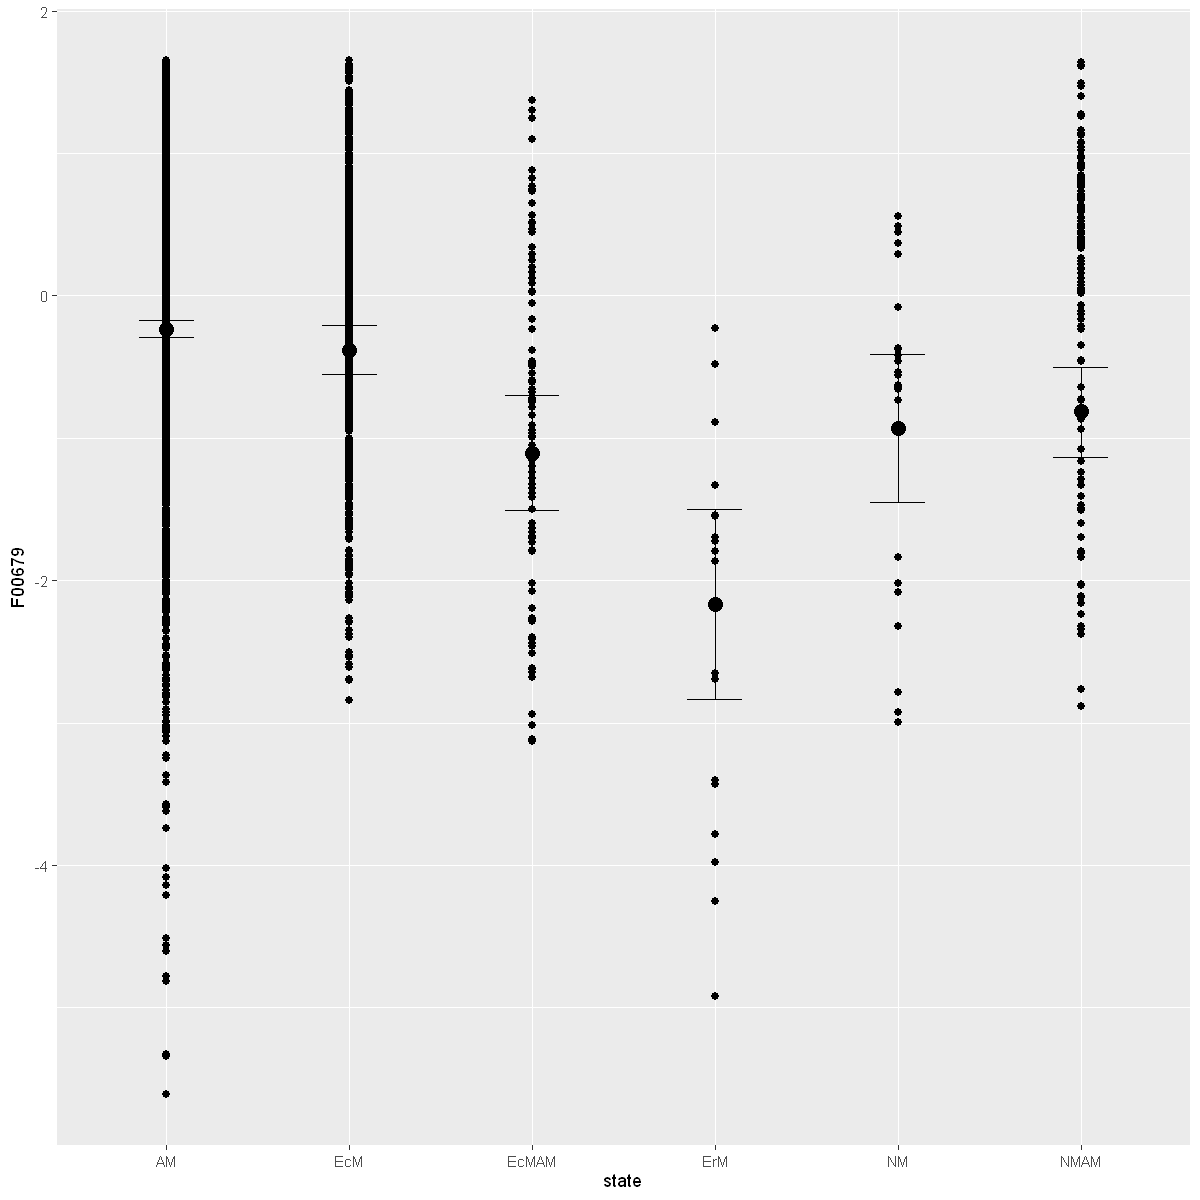

Ignoring unknown labels:
• fill : "NA"
• colour : "NA"
Ignoring unknown labels:
• fill : "NA"
• colour : "NA"


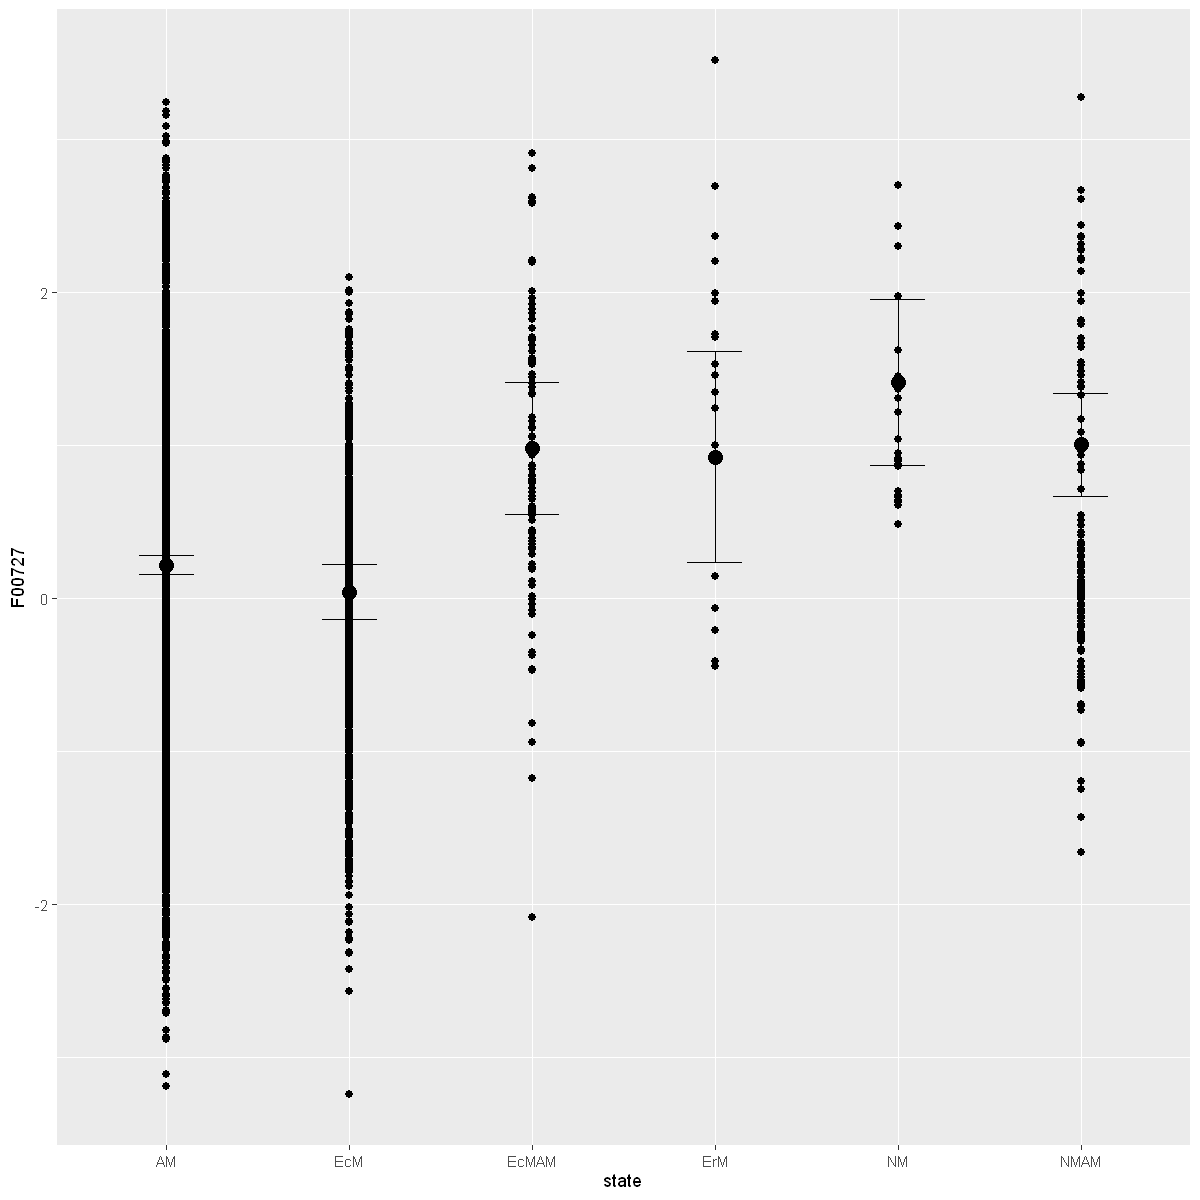

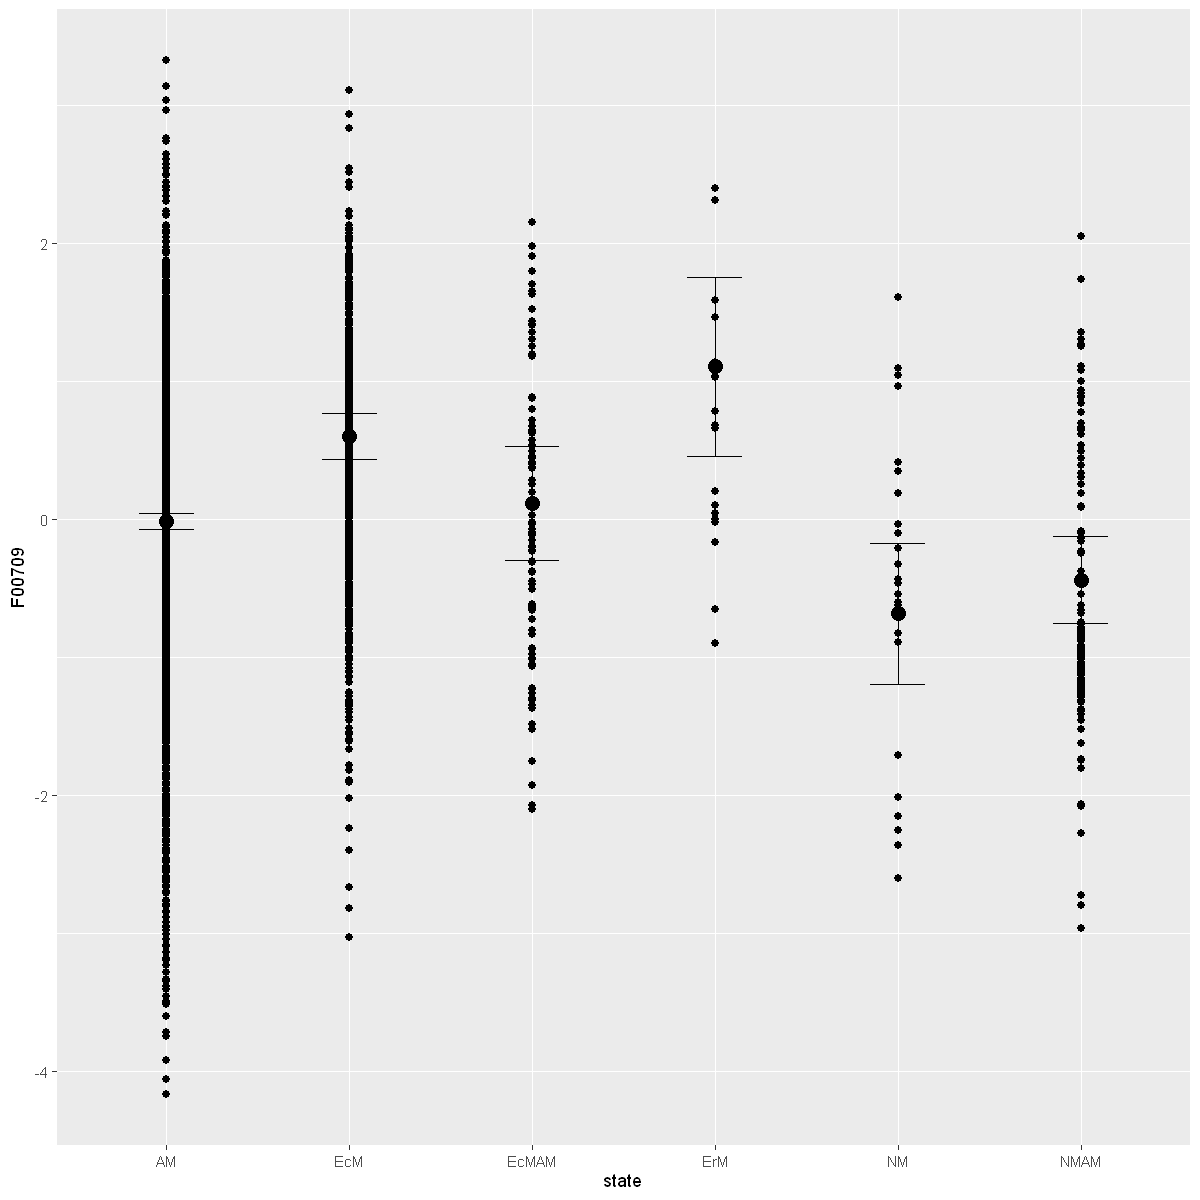

In [9]:
options(repr.plot.width = 10, repr.plot.height = 10)
plot(brms::conditional_effects(correlated_taxa, resp = "F00679"), points = TRUE)
plot(brms::conditional_effects(correlated_taxa, resp = "F00727"), points = TRUE)
plot(brms::conditional_effects(correlated_taxa, resp = "F00709"), points = TRUE)

Using 10 posterior draws for ppc type 'dens_overlay' by default.

Using 10 posterior draws for ppc type 'dens_overlay' by default.



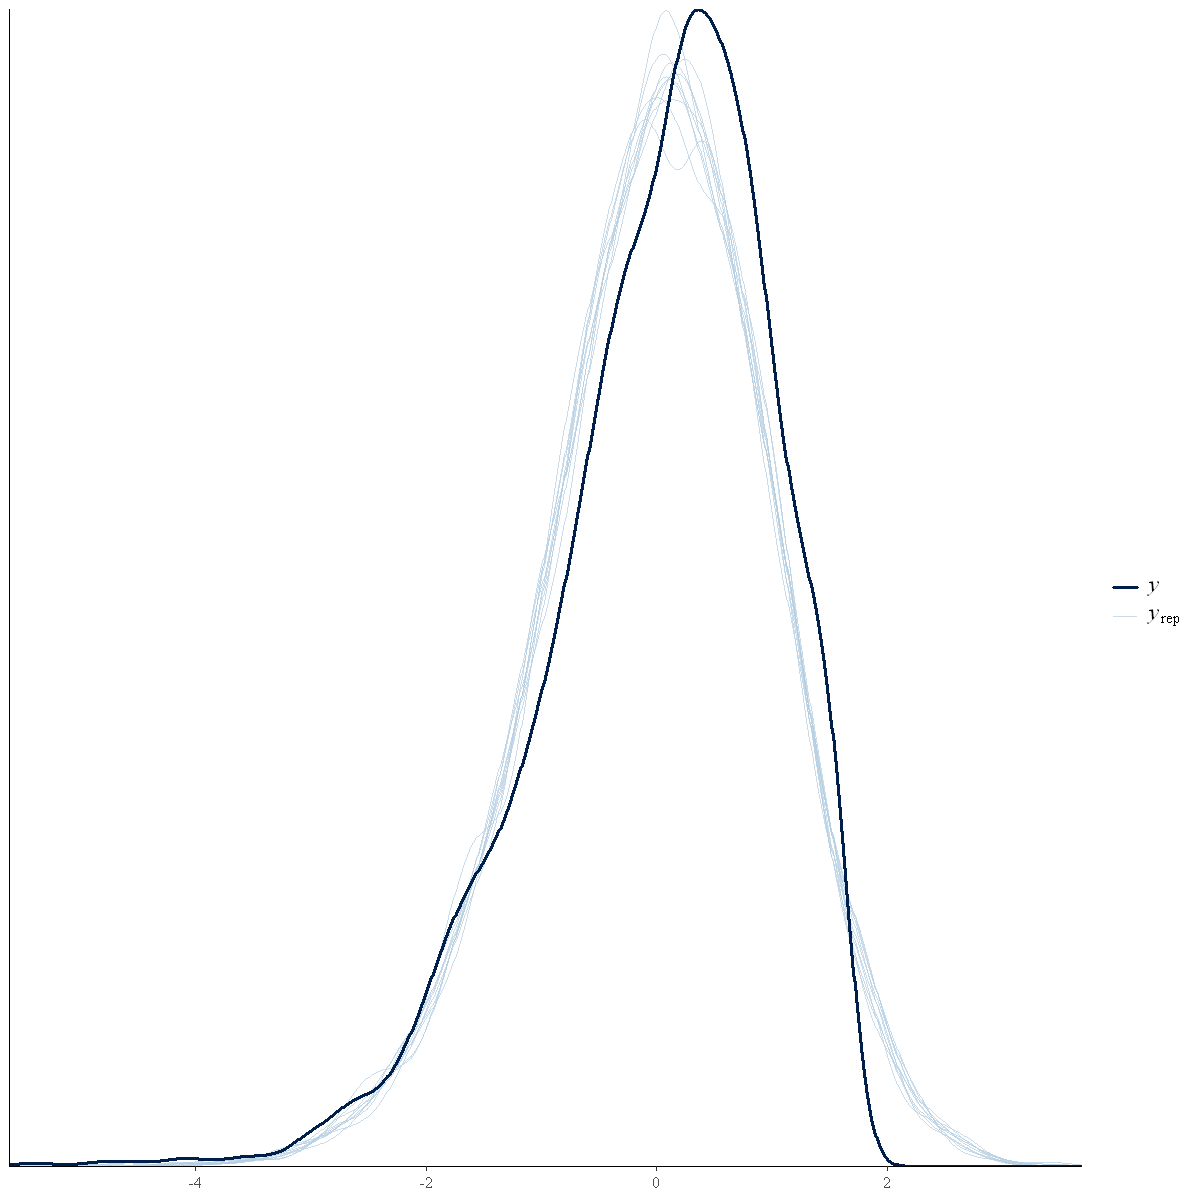

Using 10 posterior draws for ppc type 'dens_overlay' by default.



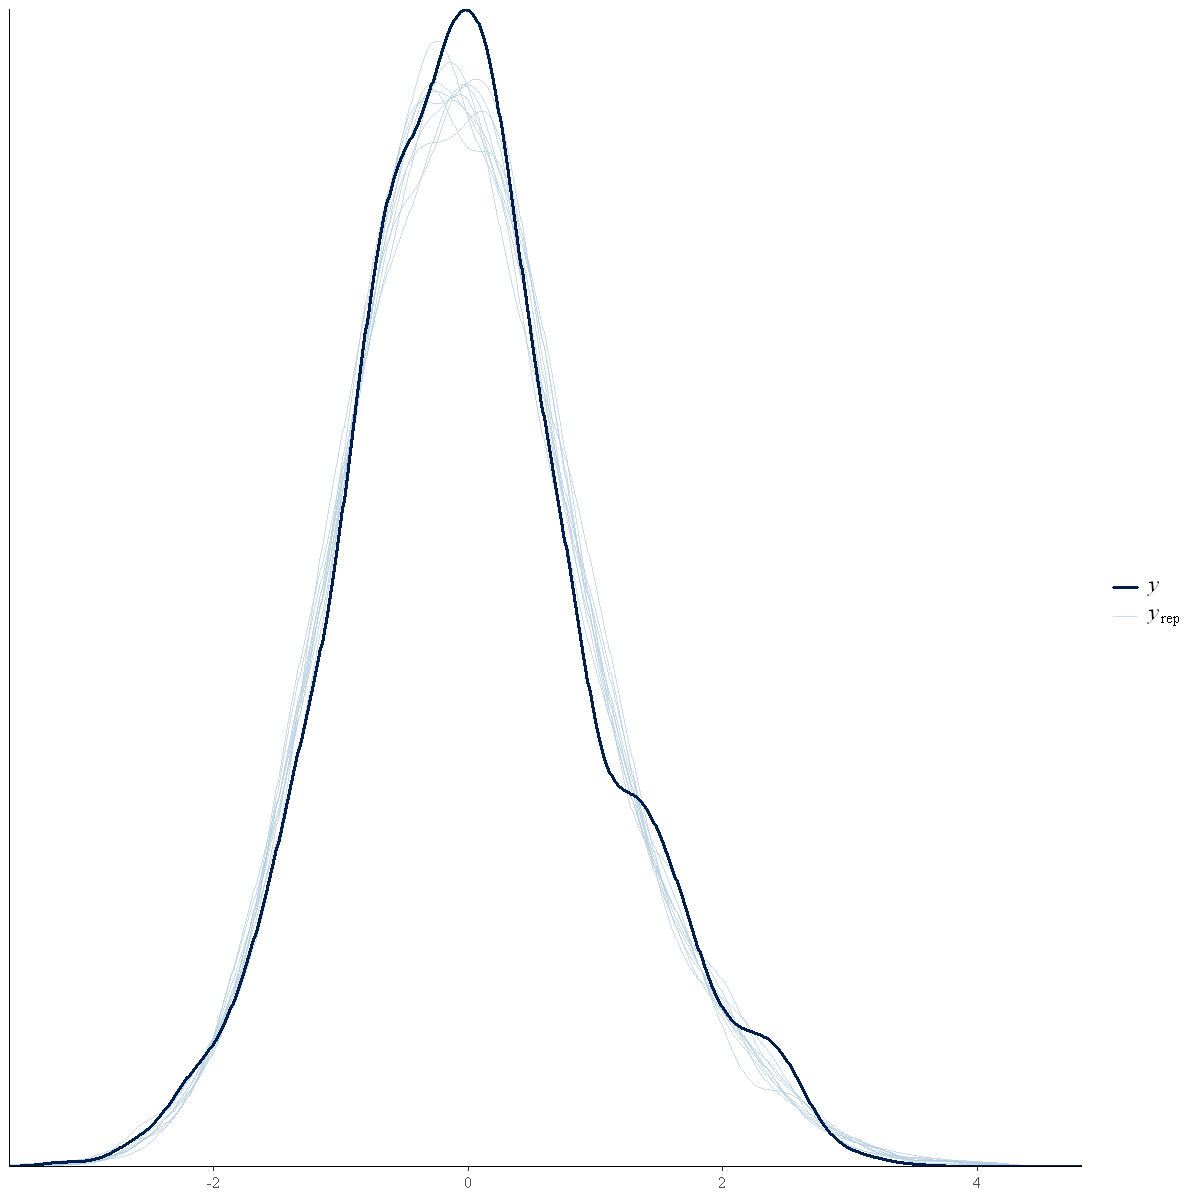

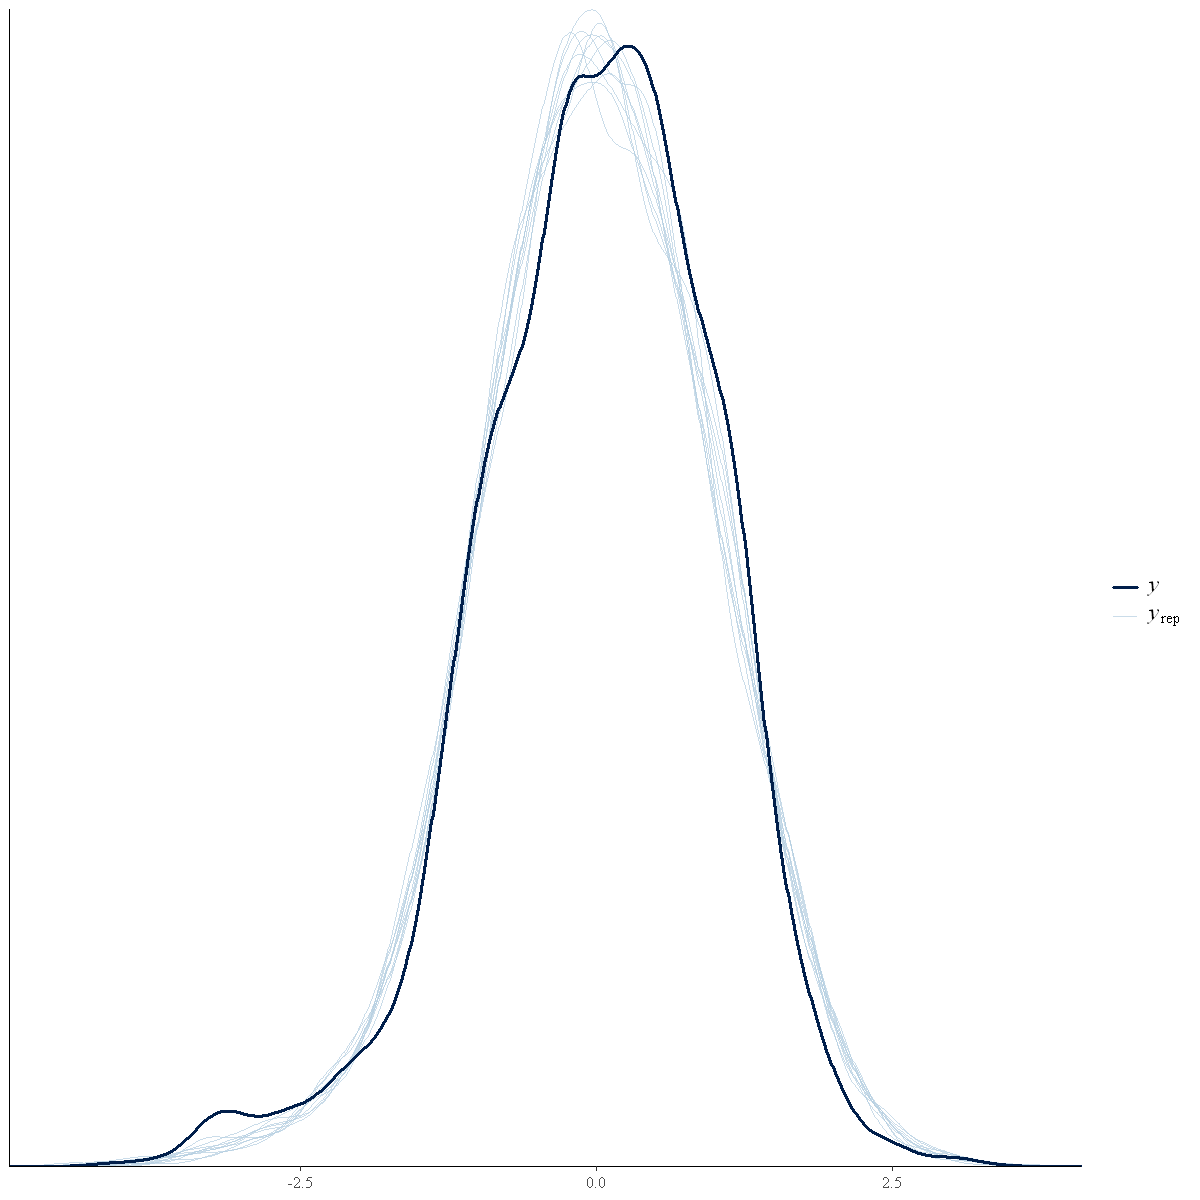

In [10]:
brms::pp_check(correlated_taxa, resp = "F00679")
brms::pp_check(correlated_taxa, resp = "F00727")
brms::pp_check(correlated_taxa, resp = "F00709")

In [11]:
brms::bayes_R2(correlated_taxa) # this is awesome

,Estimate,Est.Error,Q2.5,Q97.5
R2F00727,0.5815352,0.007522336,0.5663746,0.5959299
R2F00679,0.5202709,0.008479031,0.5032777,0.5365578
R2F00709,0.6504595,0.006031641,0.6383486,0.6619273


In [3]:
simple_brms <- readRDS("../../data/chapter2/rdata/brms_model_1.Rds")

In [21]:
summary(simple_brms)

 Family: MV(gaussian, gaussian, gaussian) 
  Links: mu = identity
         mu = identity
         mu = identity 
Formula: F00727 ~ state + (1 | p | taxa) 
         F00679 ~ state + (1 | p | taxa) 
         F00709 ~ state + (1 | p | taxa) 
   Data: fred4 (Number of observations: 5218) 
  Draws: 6 chains, each with iter = 10000; warmup = 5000; thin = 1;
         total post-warmup draws = 30000

Multilevel Hyperparameters:
~taxa (Number of levels: 1301) 
                                       Estimate Est.Error l-95% CI u-95% CI
sd(F00727_Intercept)                       0.91      0.02     0.87     0.96
sd(F00679_Intercept)                       0.83      0.02     0.78     0.87
sd(F00709_Intercept)                       0.87      0.02     0.83     0.91
cor(F00727_Intercept,F00679_Intercept)    -0.78      0.02    -0.81    -0.74
cor(F00727_Intercept,F00709_Intercept)    -0.60      0.02    -0.65    -0.56
cor(F00679_Intercept,F00709_Intercept)     0.01      0.04    -0.06     0.09
            

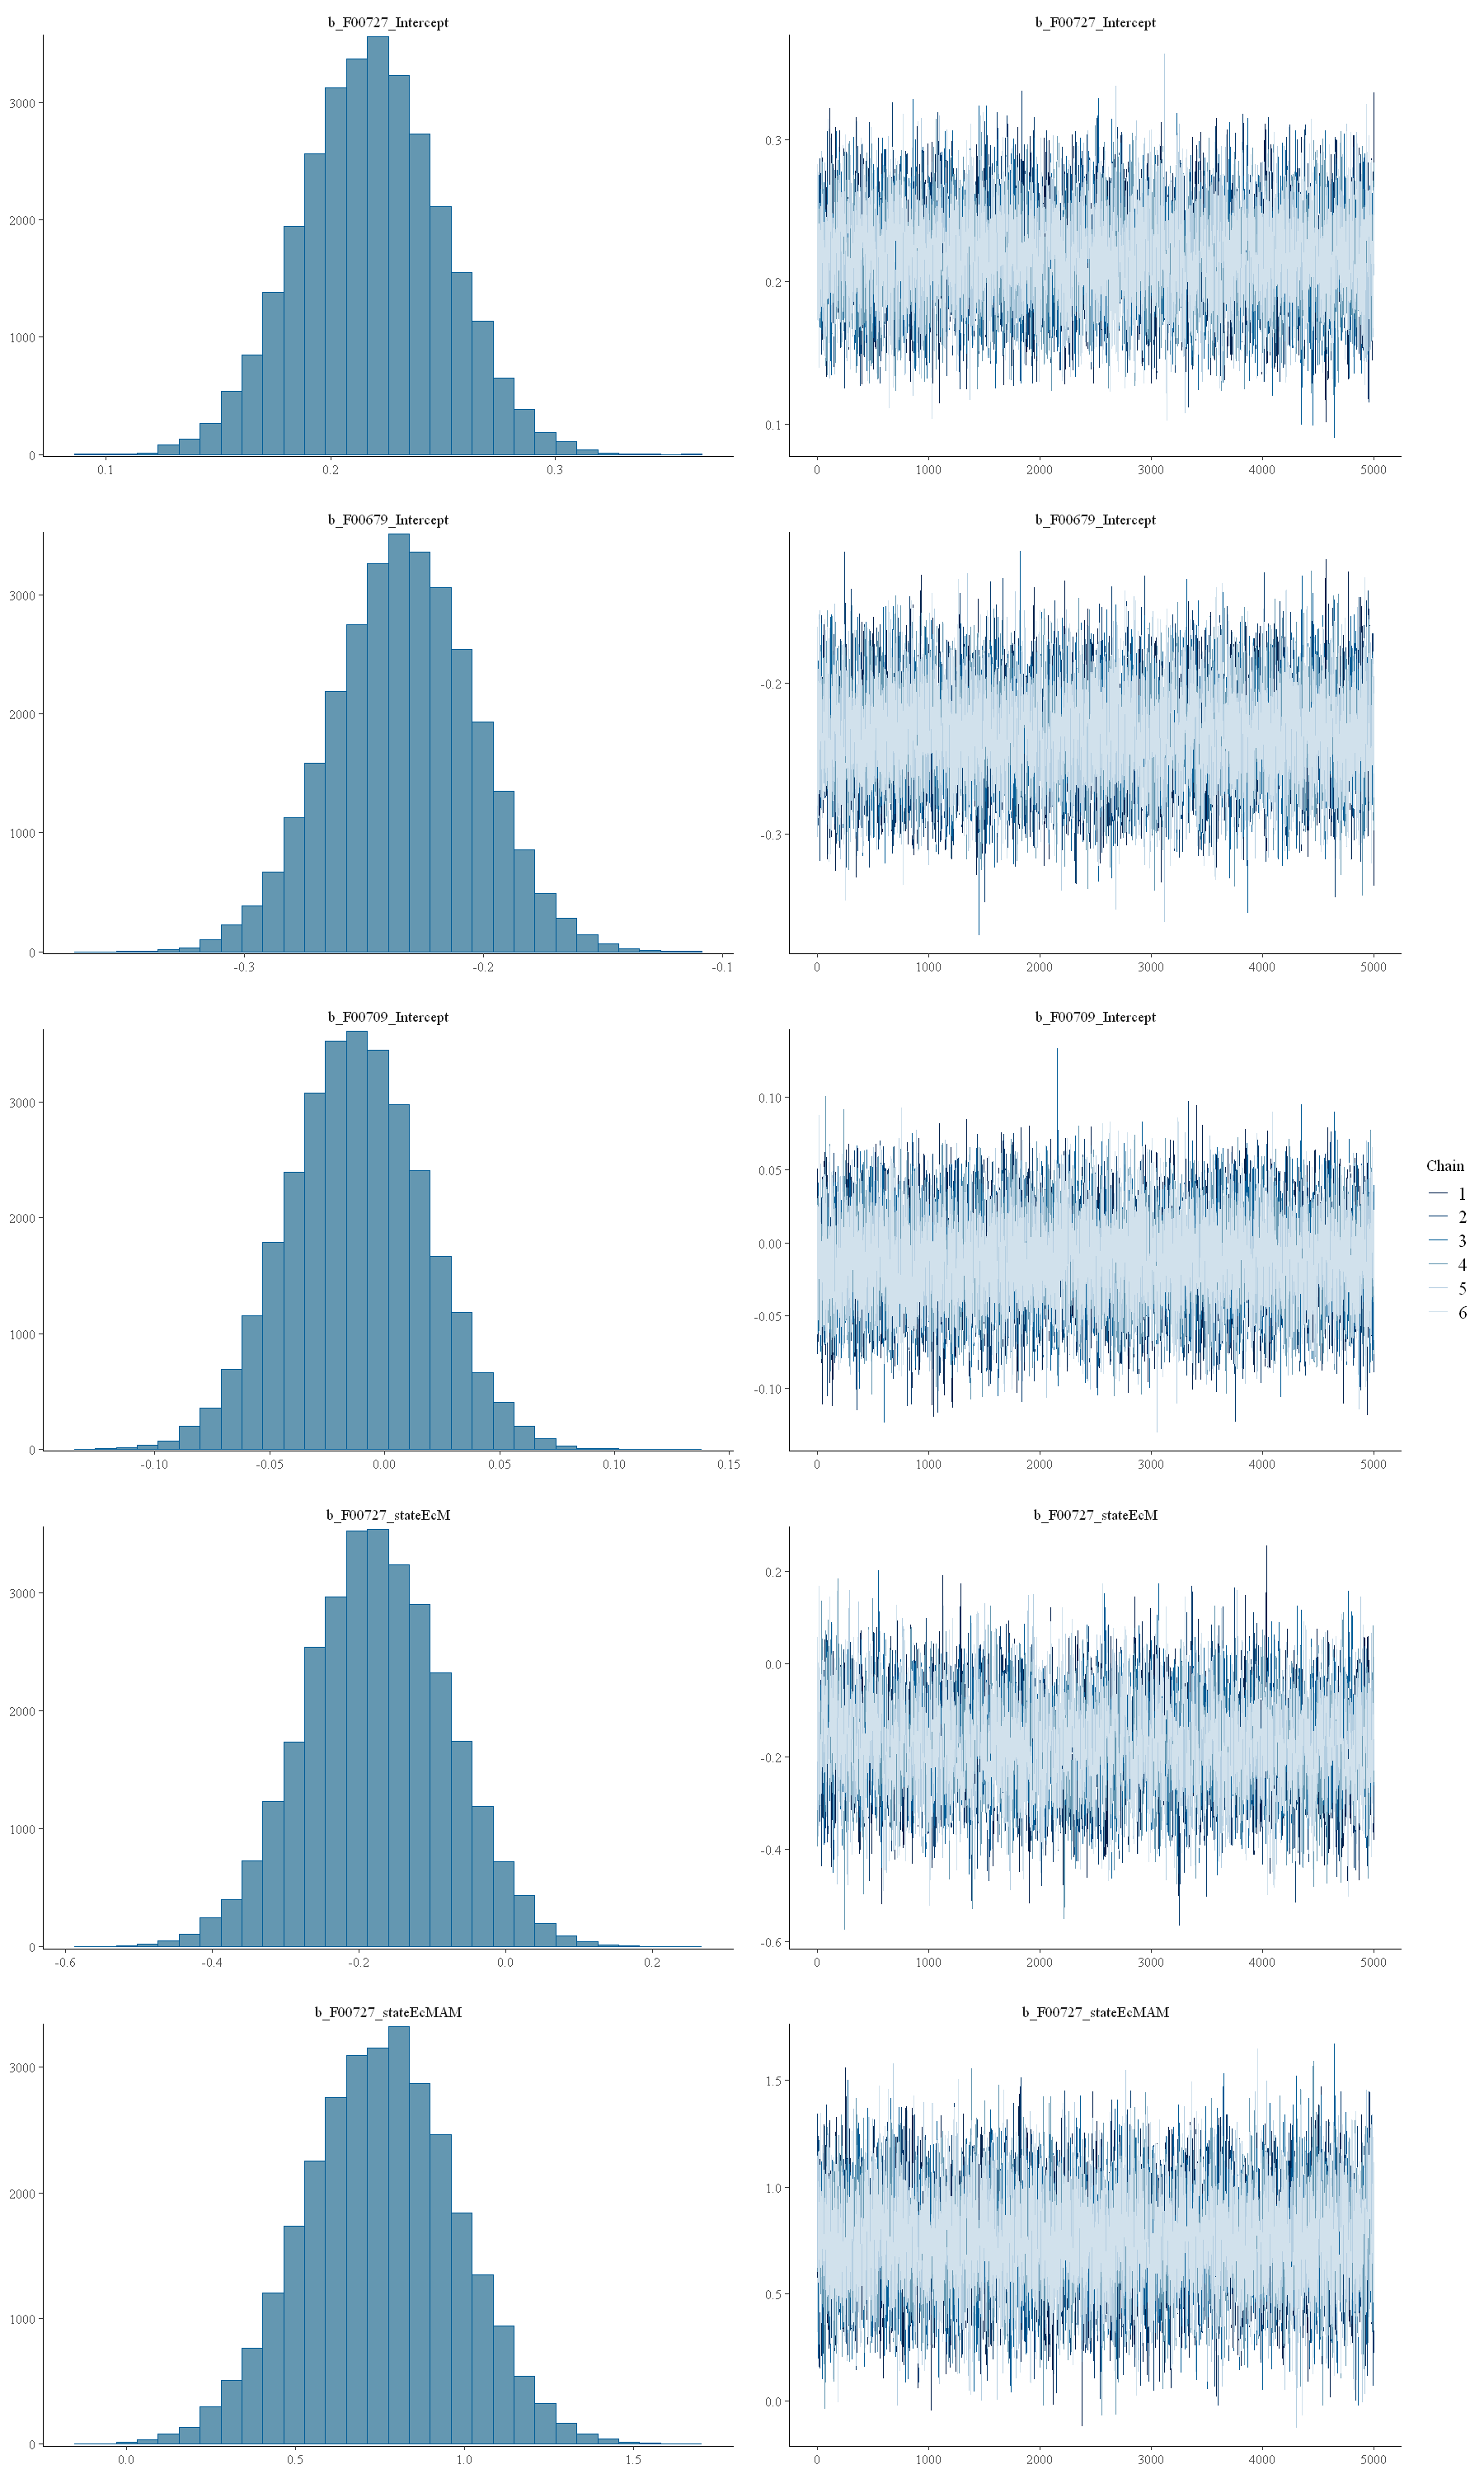

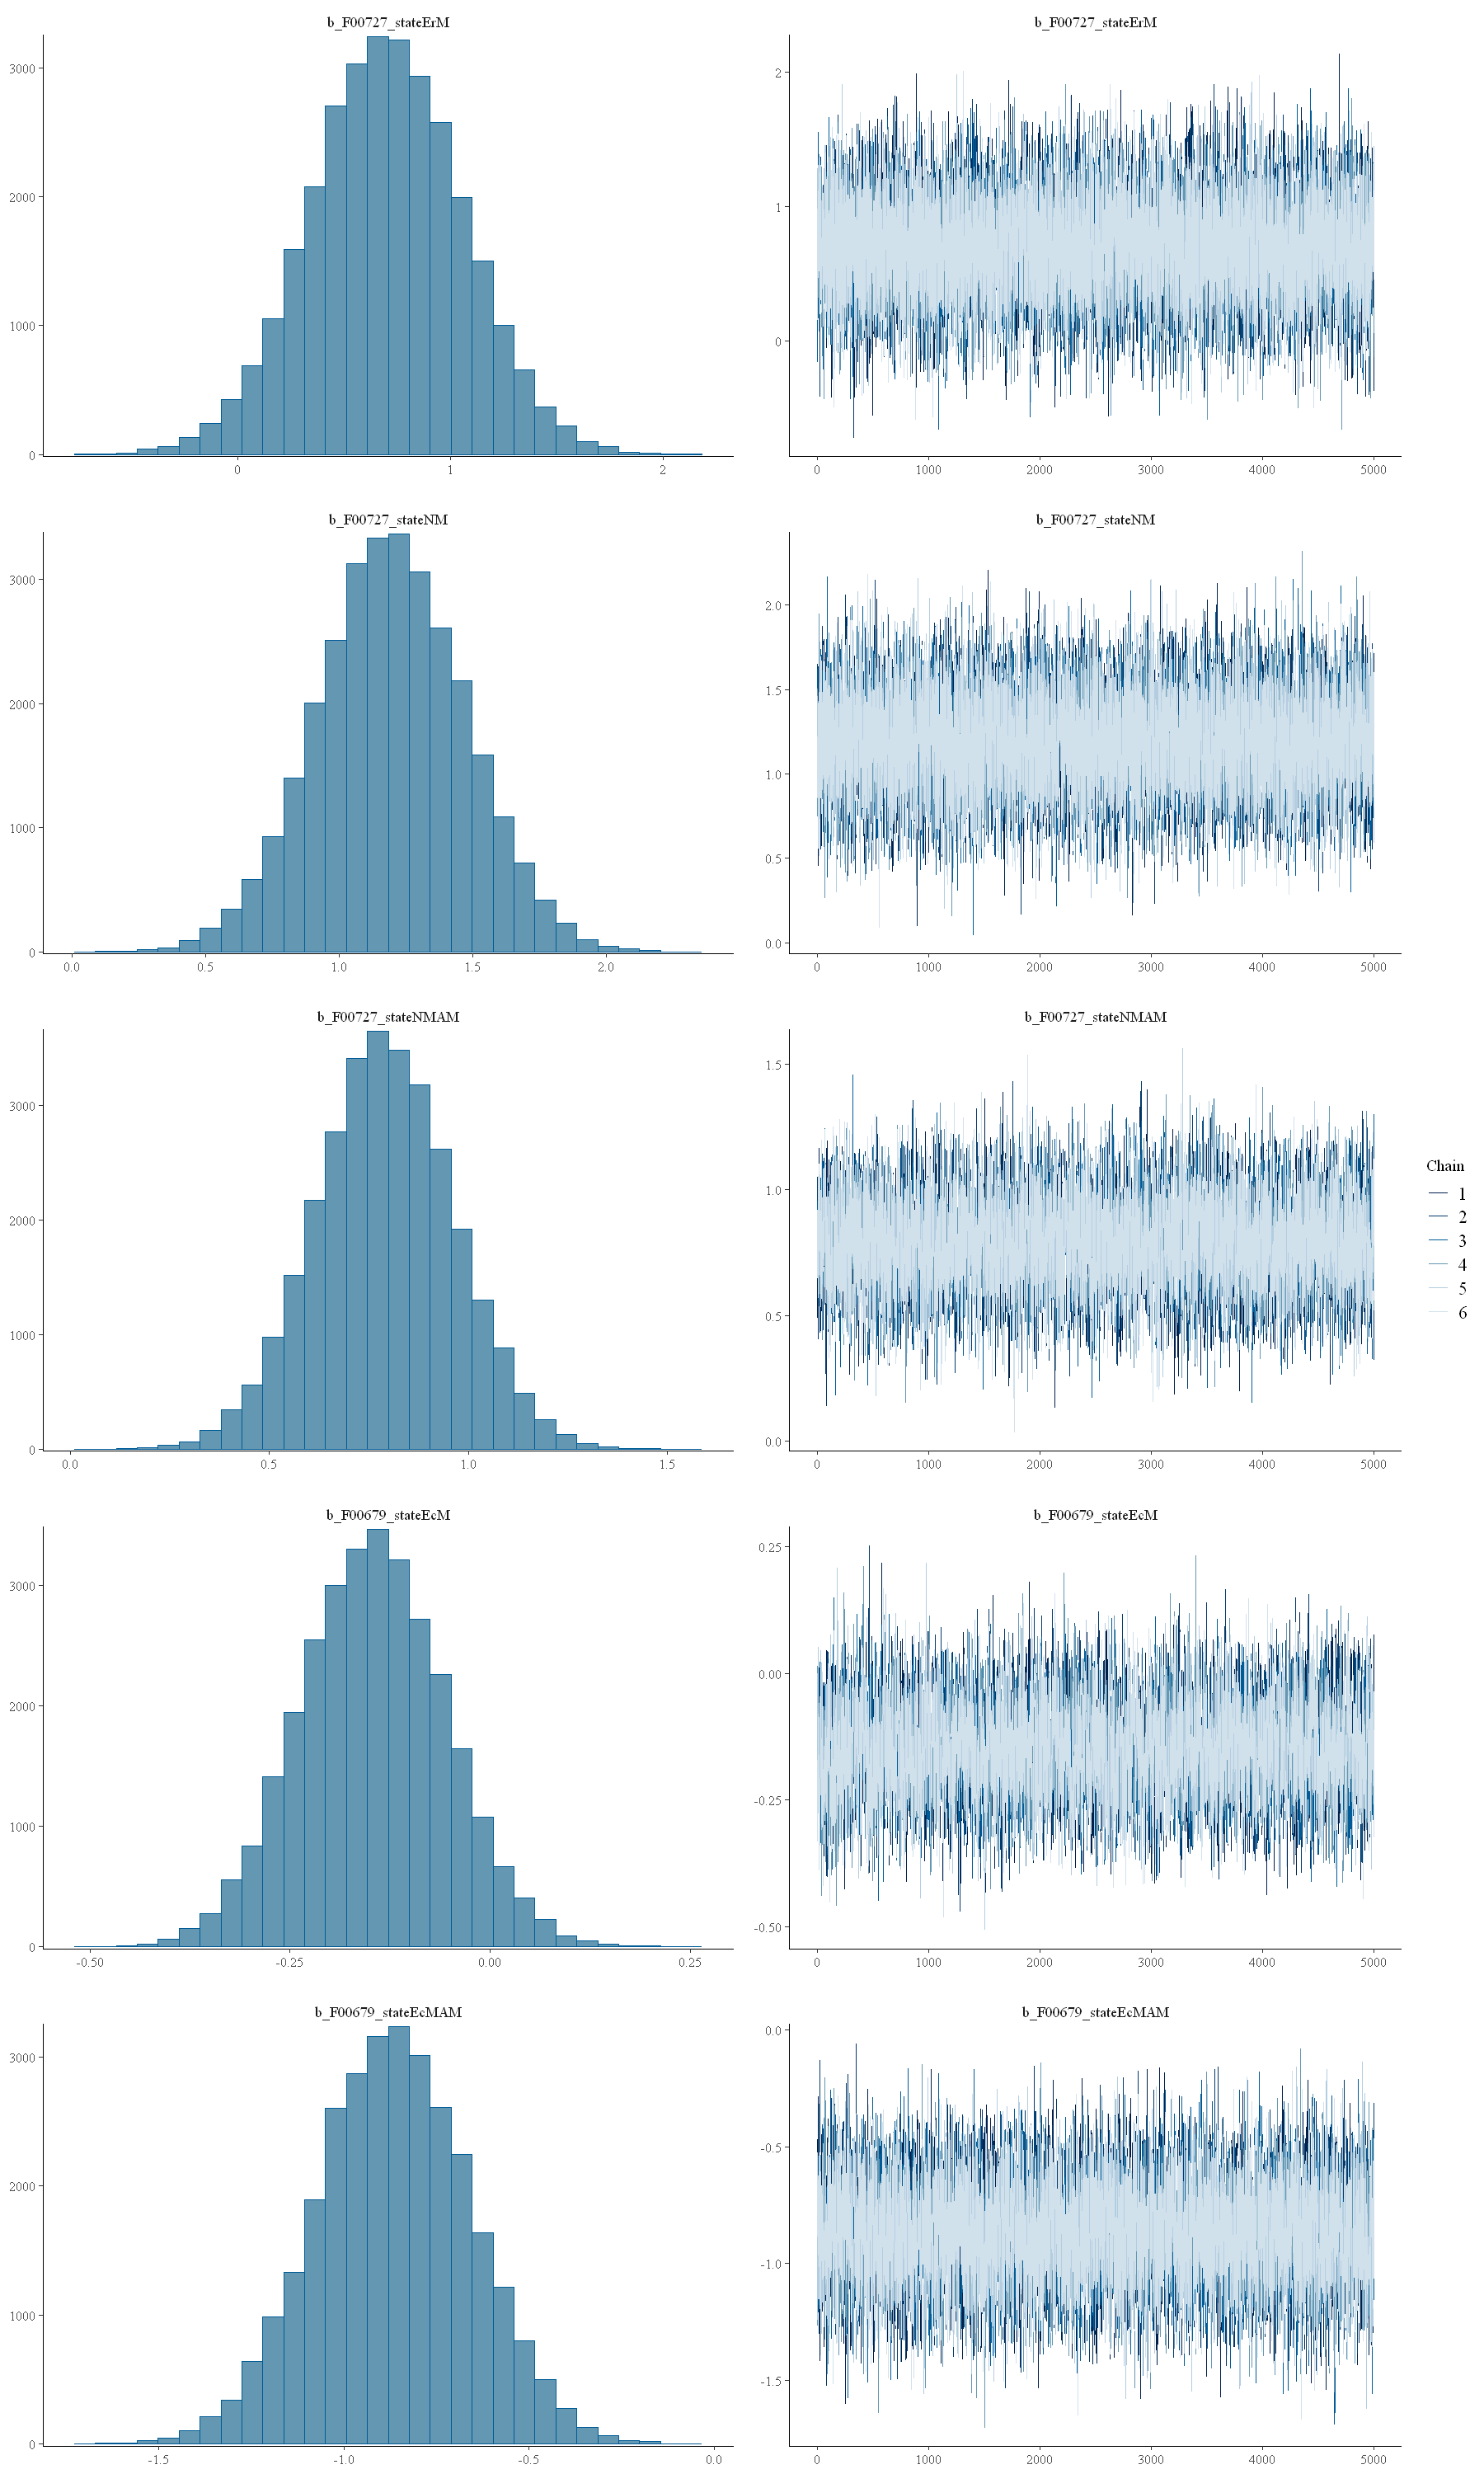

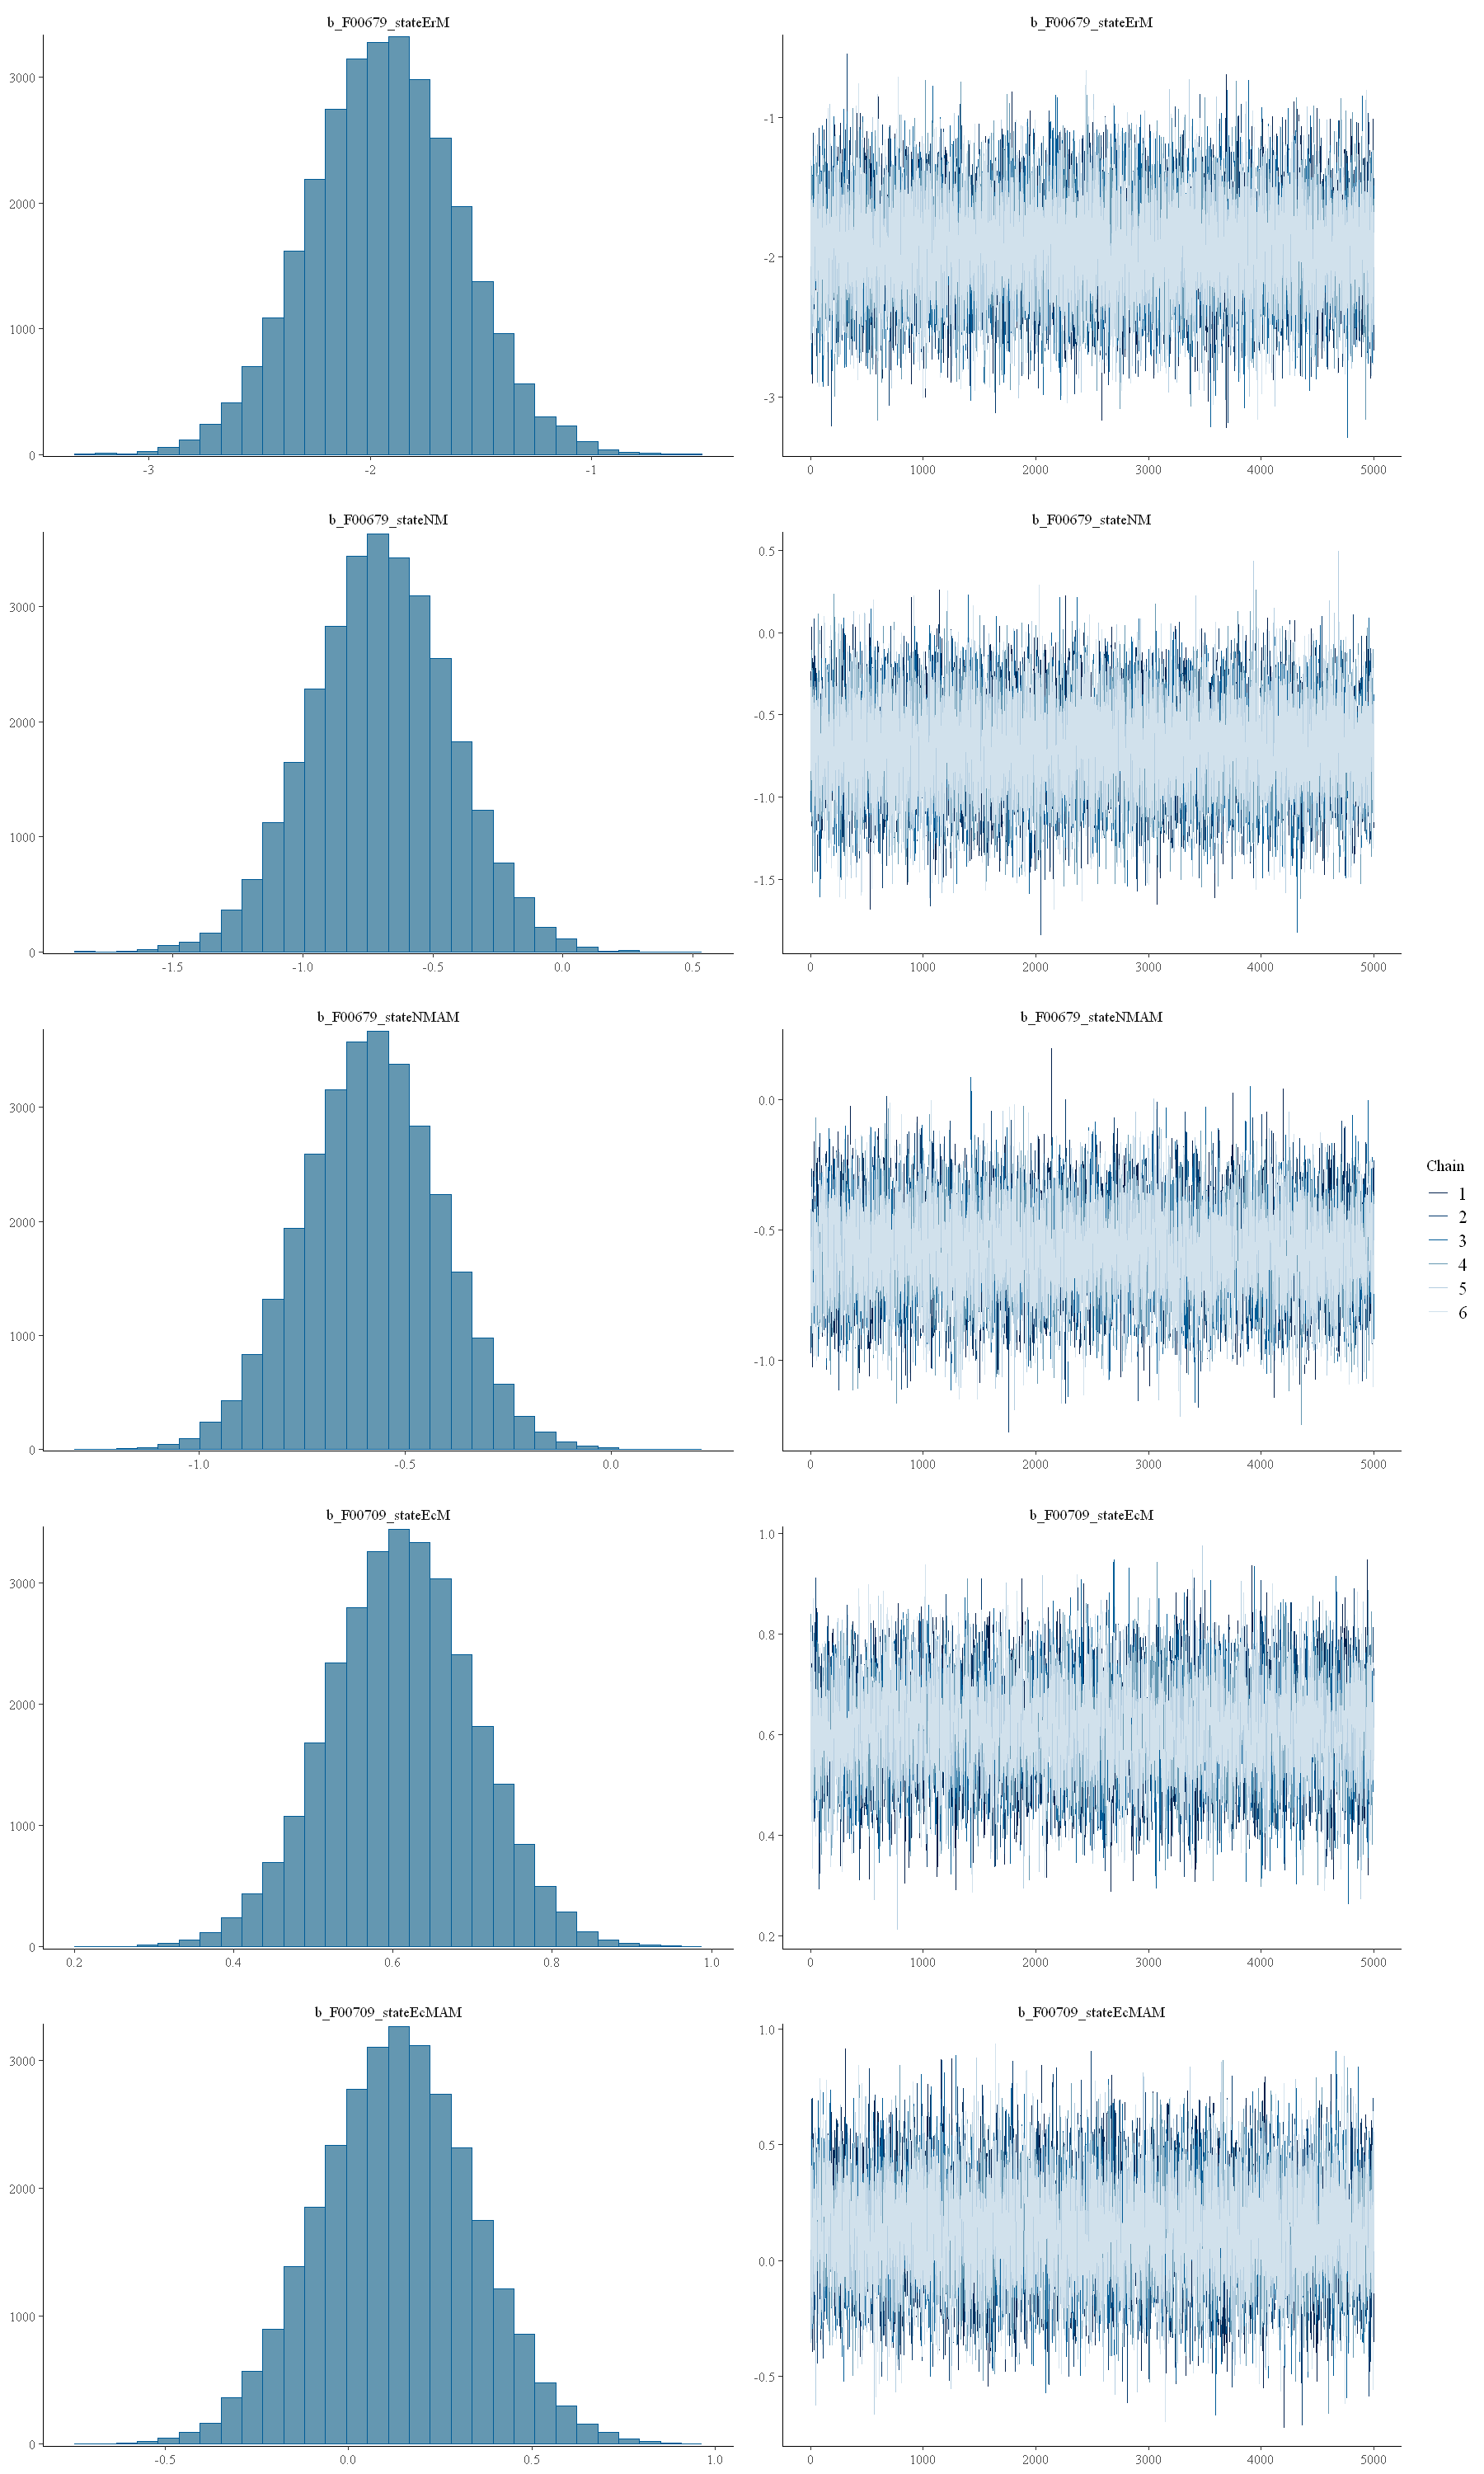

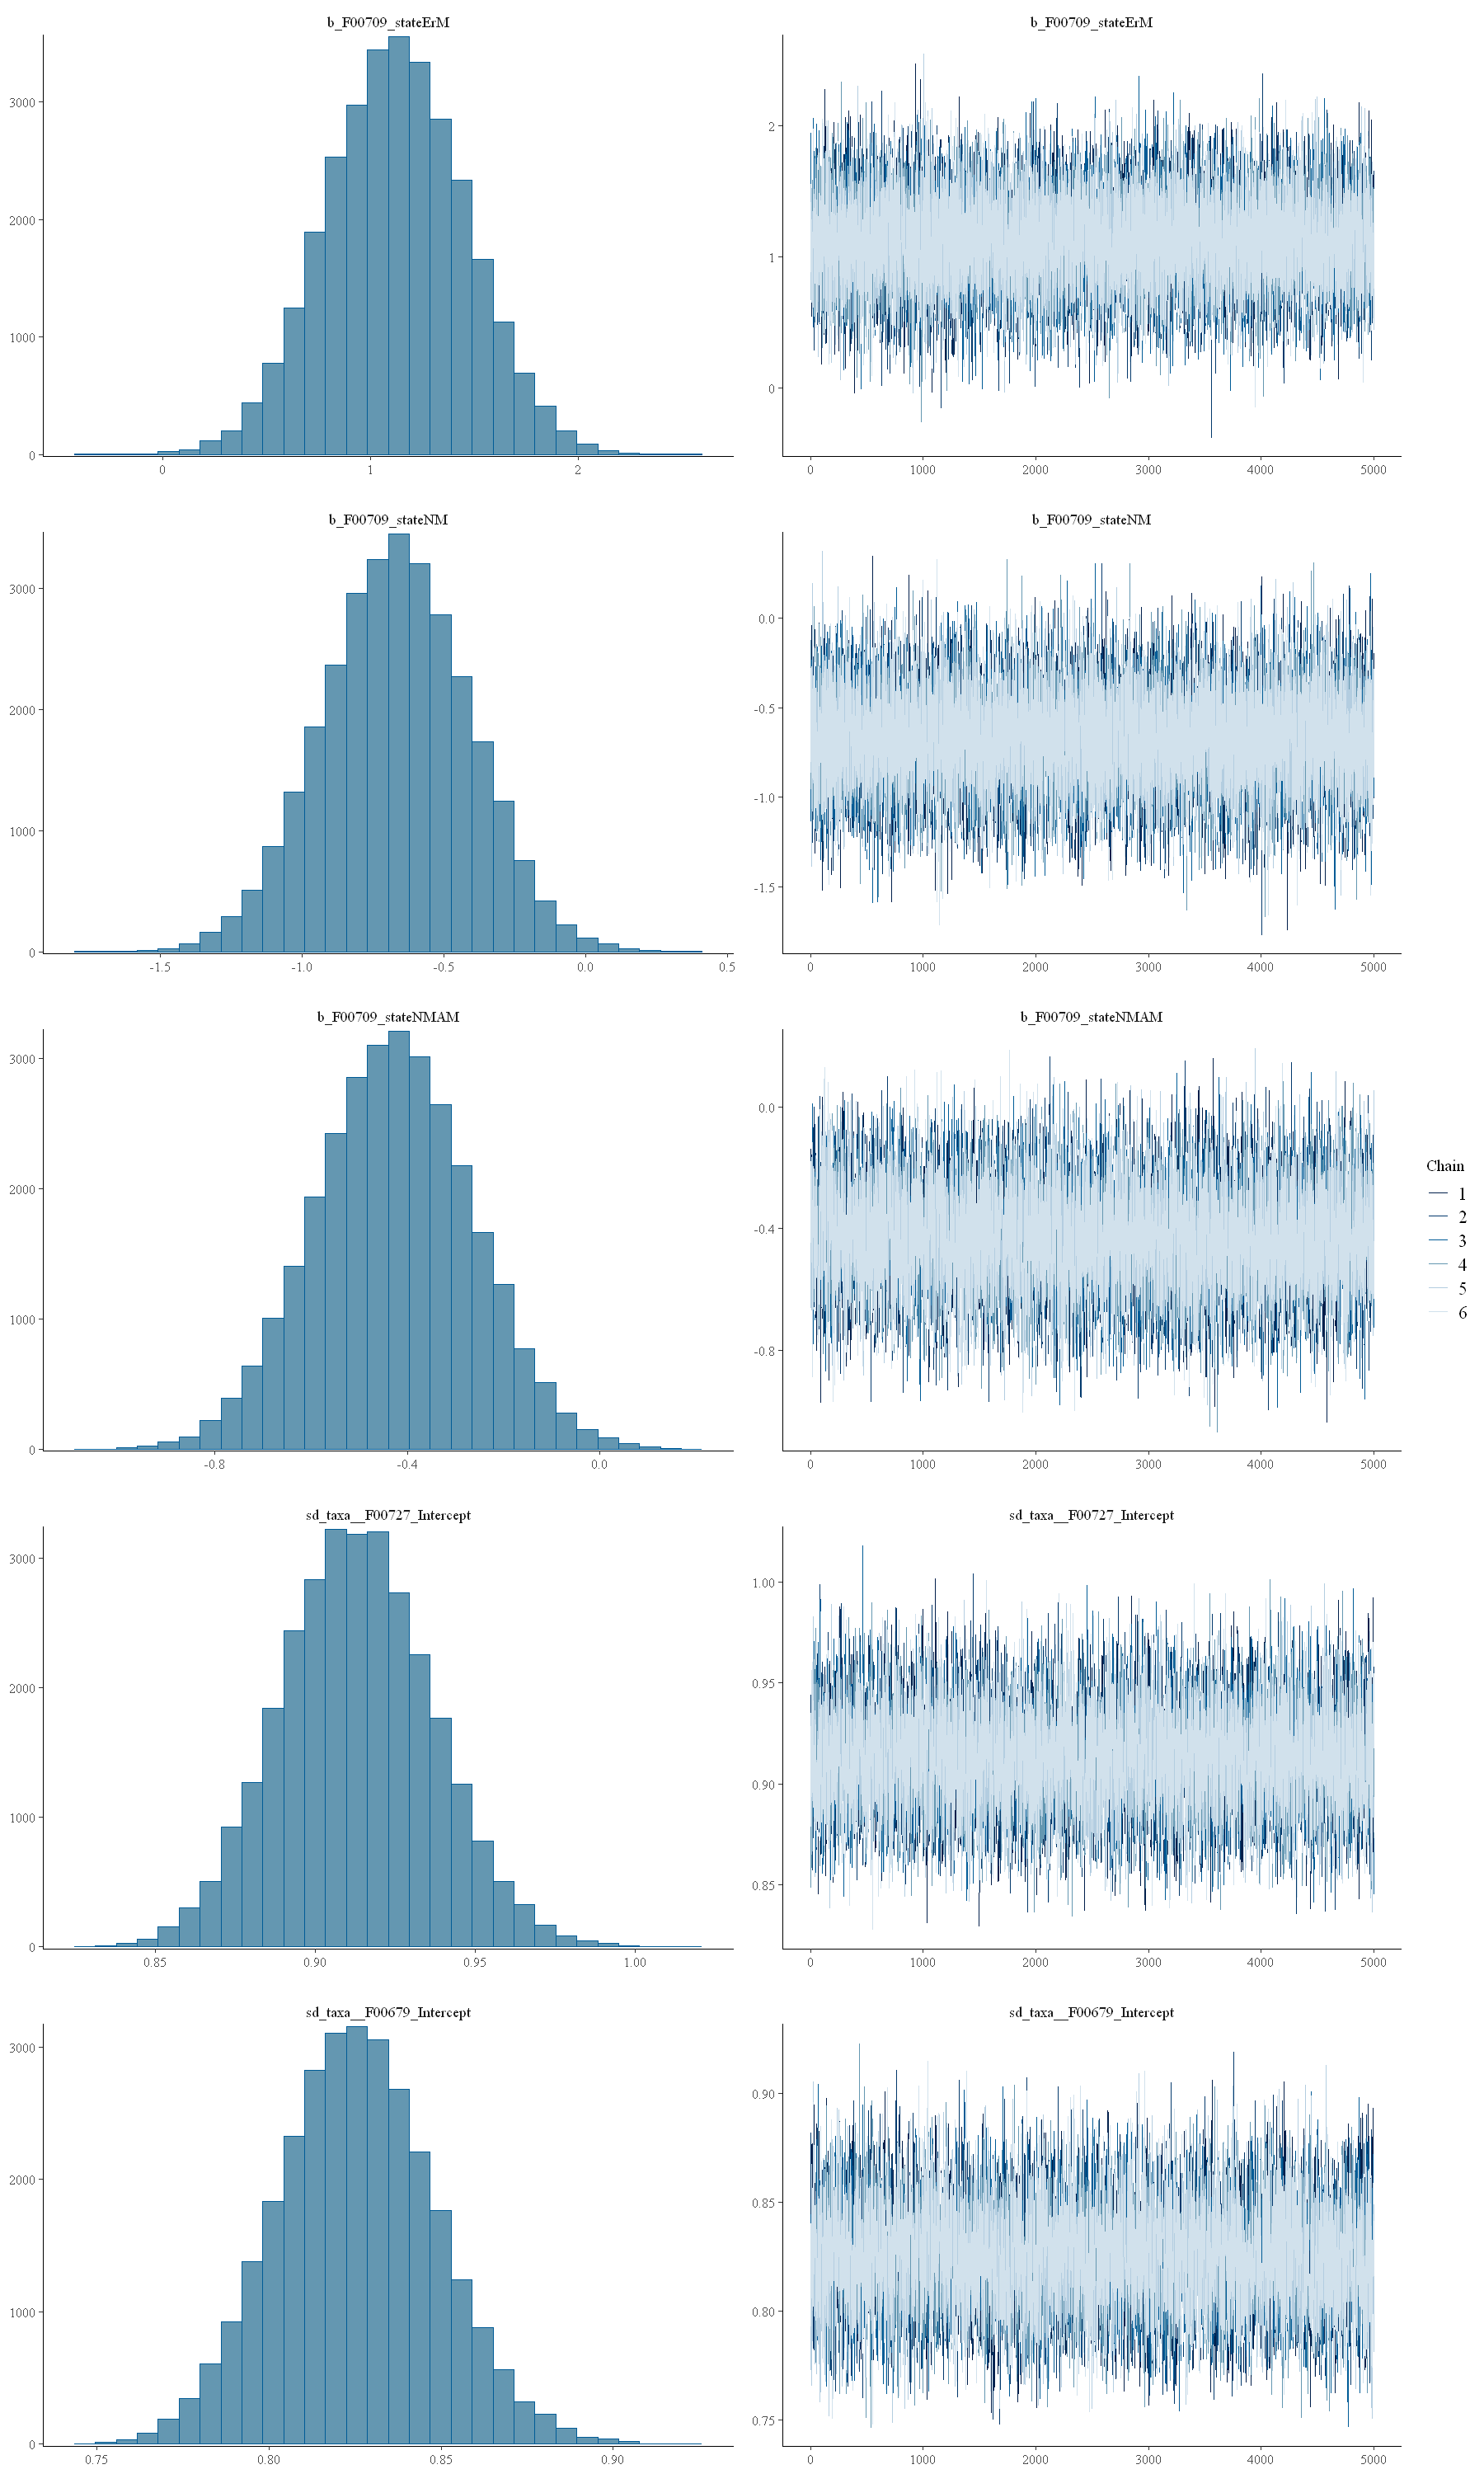

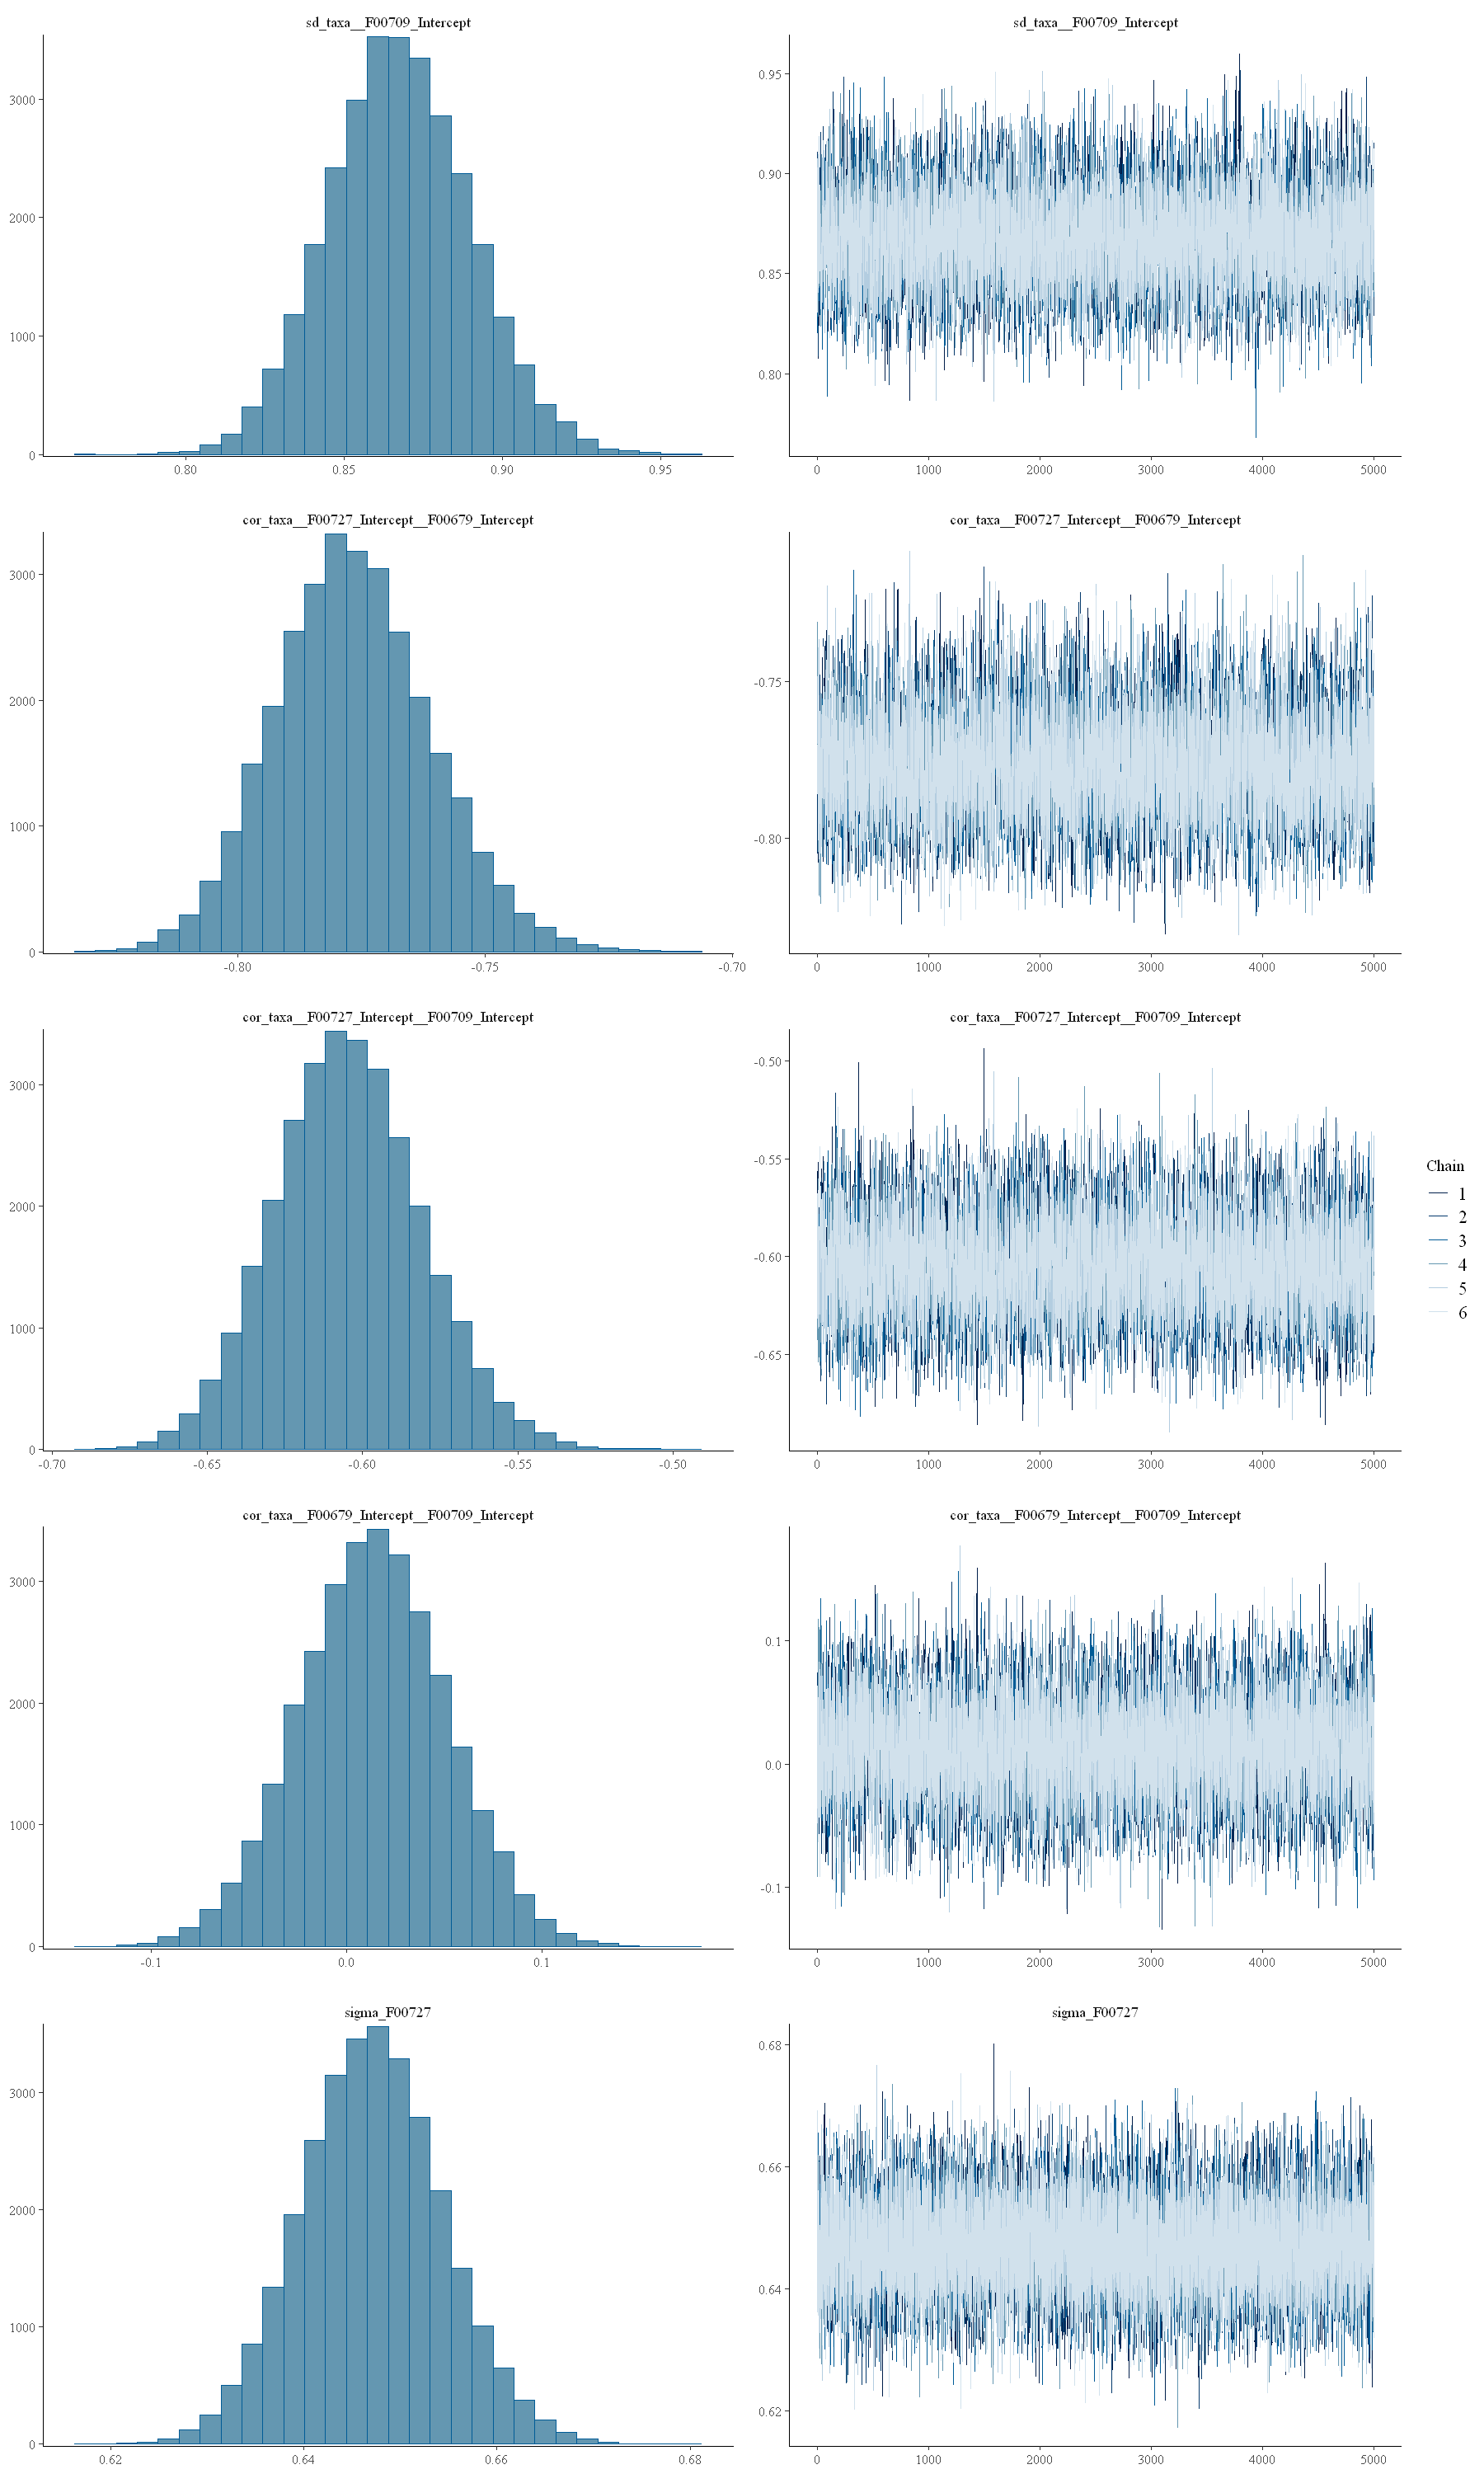

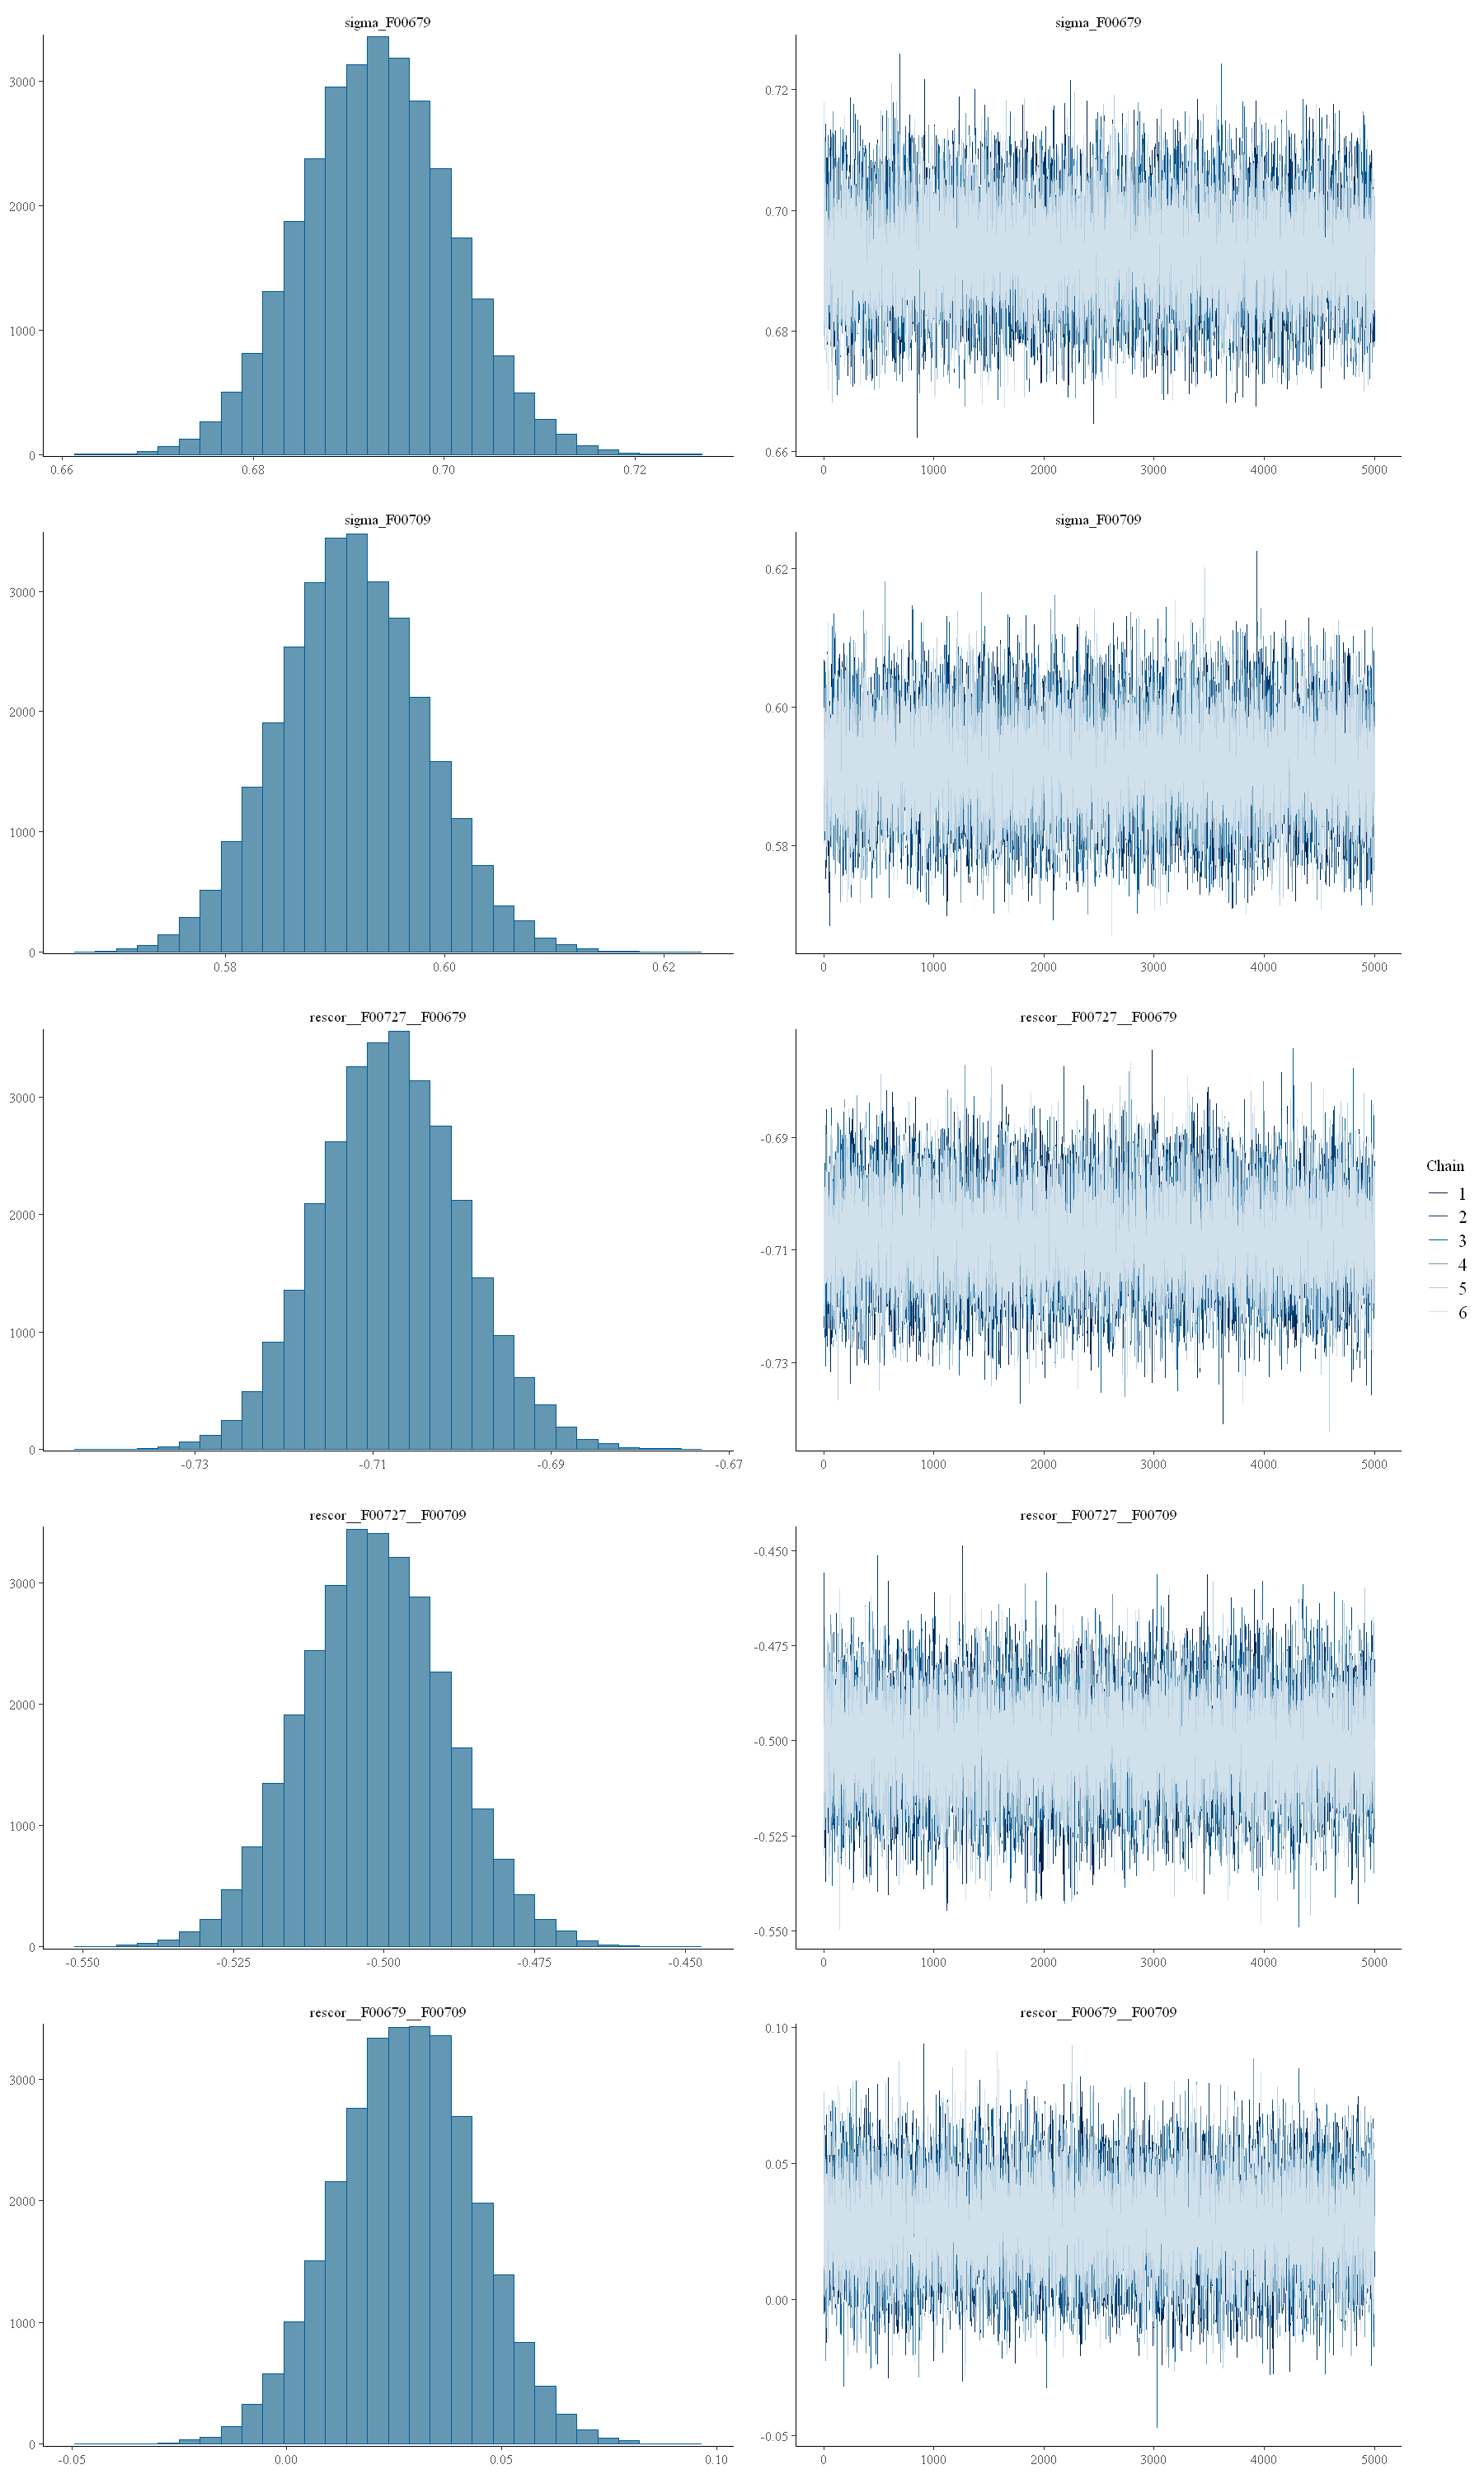

In [22]:
options(repr.plot.width = 15, repr.plot.height = 25)
plot(simple_brms)

Ignoring unknown labels:
• fill : "NA"
• colour : "NA"
Ignoring unknown labels:
• fill : "NA"
• colour : "NA"
Ignoring unknown labels:
• fill : "NA"
• colour : "NA"
Ignoring unknown labels:
• fill : "NA"
• colour : "NA"


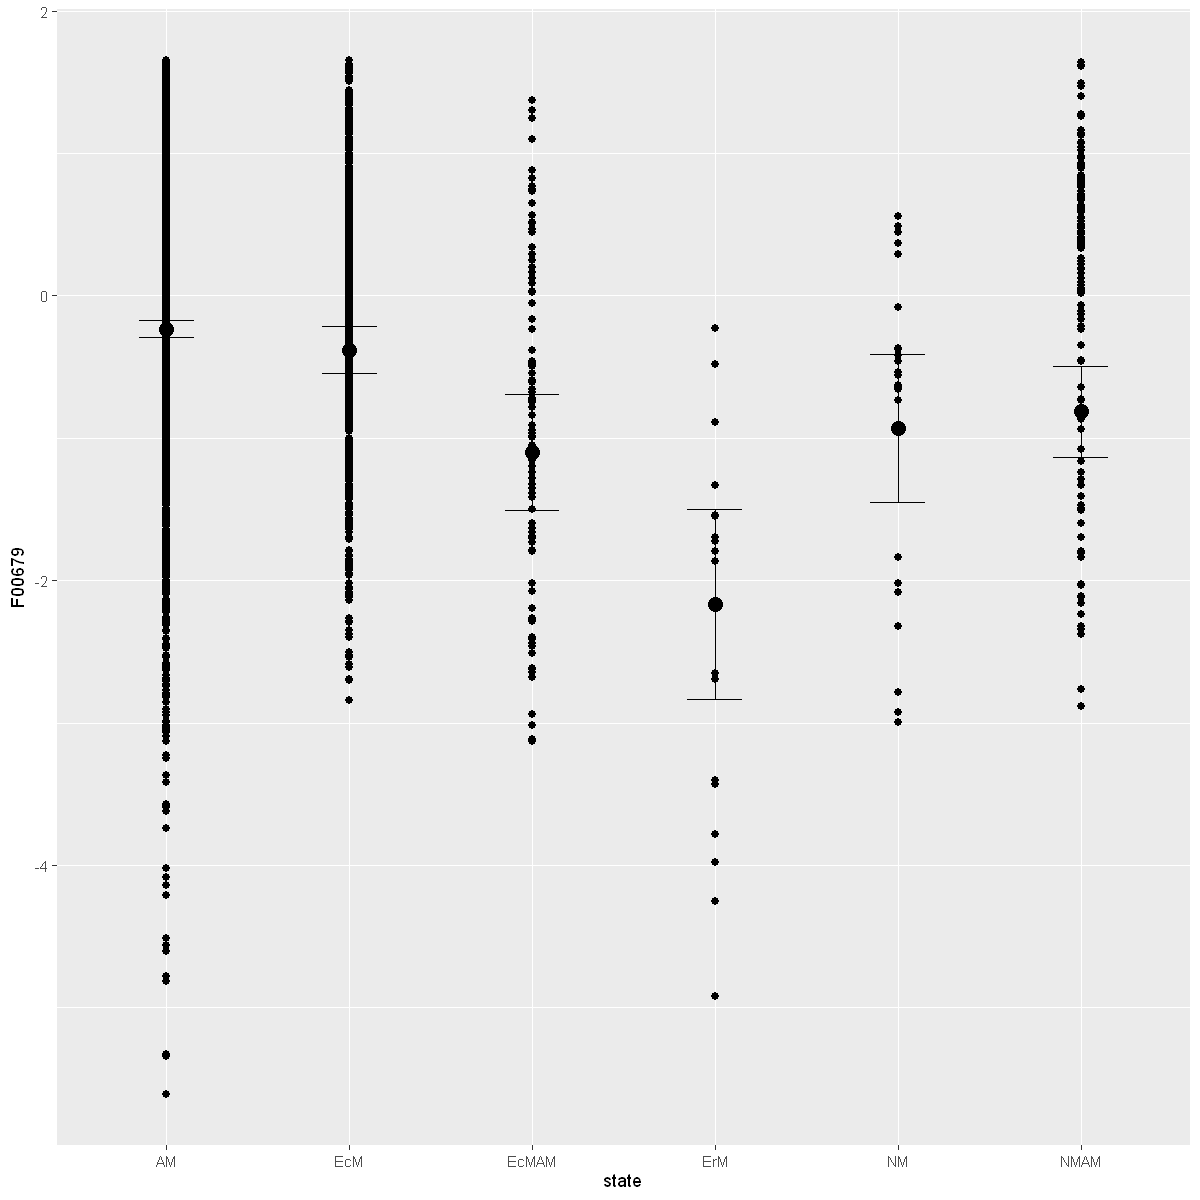

Ignoring unknown labels:
• fill : "NA"
• colour : "NA"
Ignoring unknown labels:
• fill : "NA"
• colour : "NA"


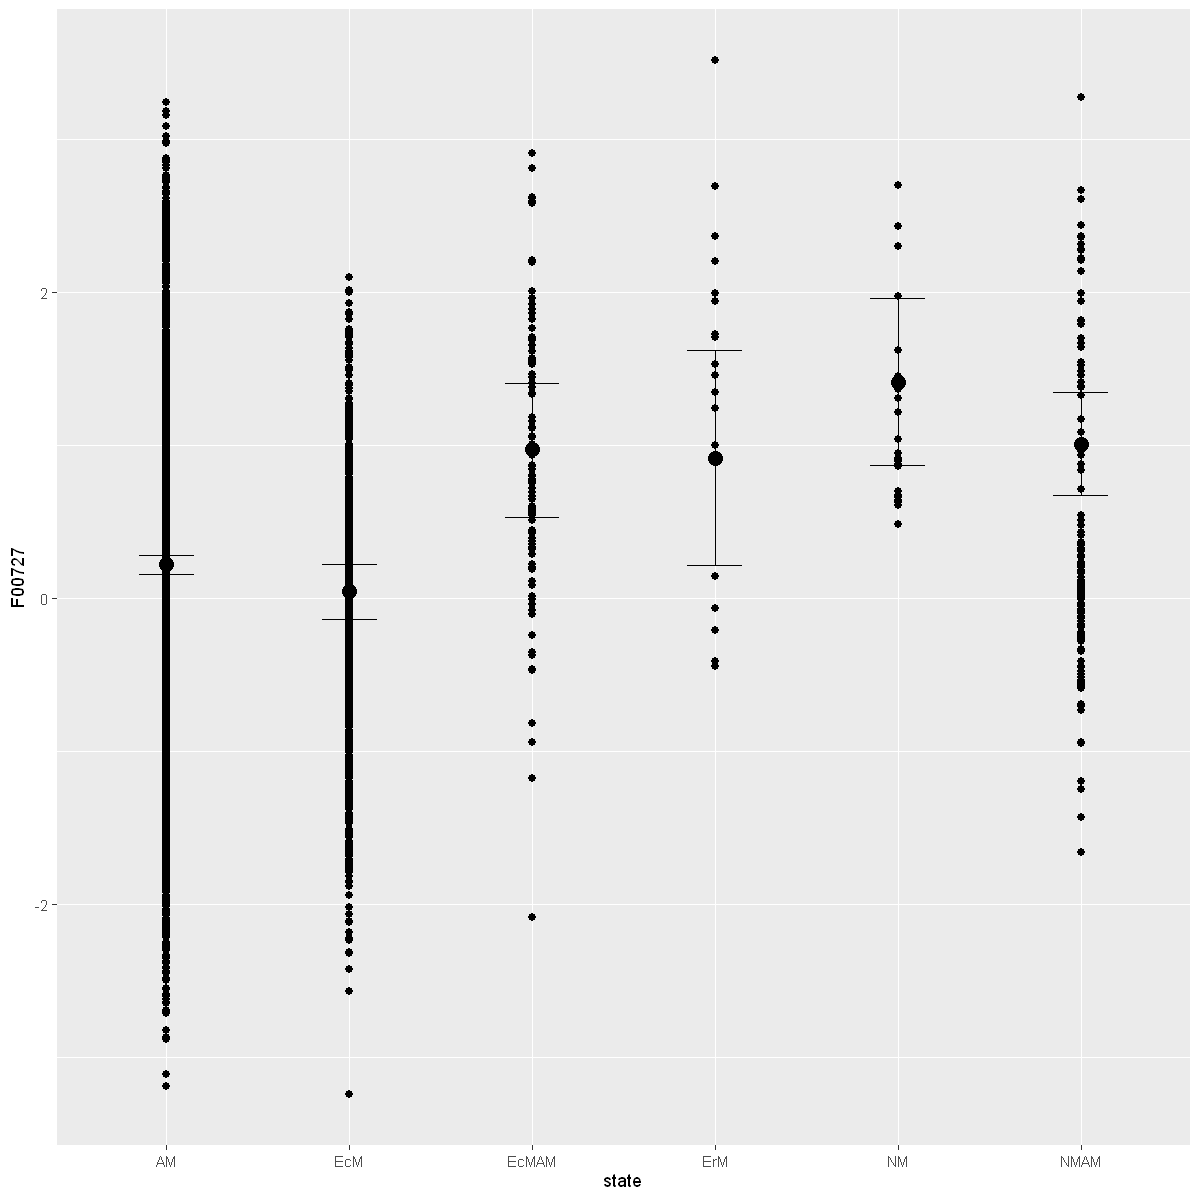

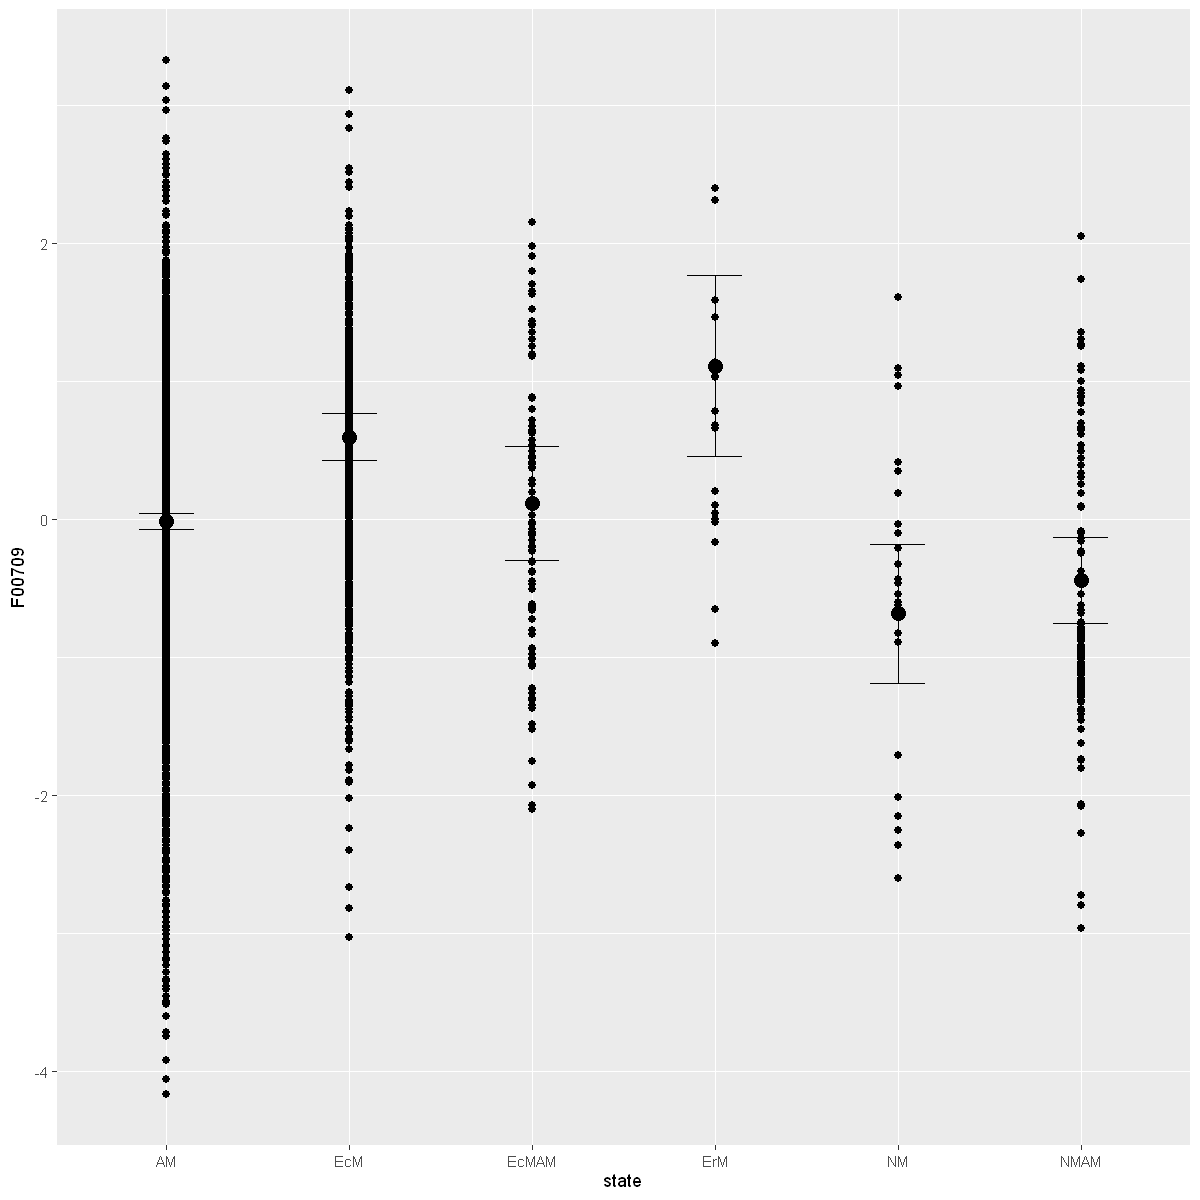

In [23]:
options(repr.plot.width = 10, repr.plot.height = 10)
plot(brms::conditional_effects(simple_brms, resp = "F00679"), points = TRUE)
plot(brms::conditional_effects(simple_brms, resp = "F00727"), points = TRUE)
plot(brms::conditional_effects(simple_brms, resp = "F00709"), points = TRUE)

Using 10 posterior draws for ppc type 'dens_overlay' by default.

Using 10 posterior draws for ppc type 'dens_overlay' by default.



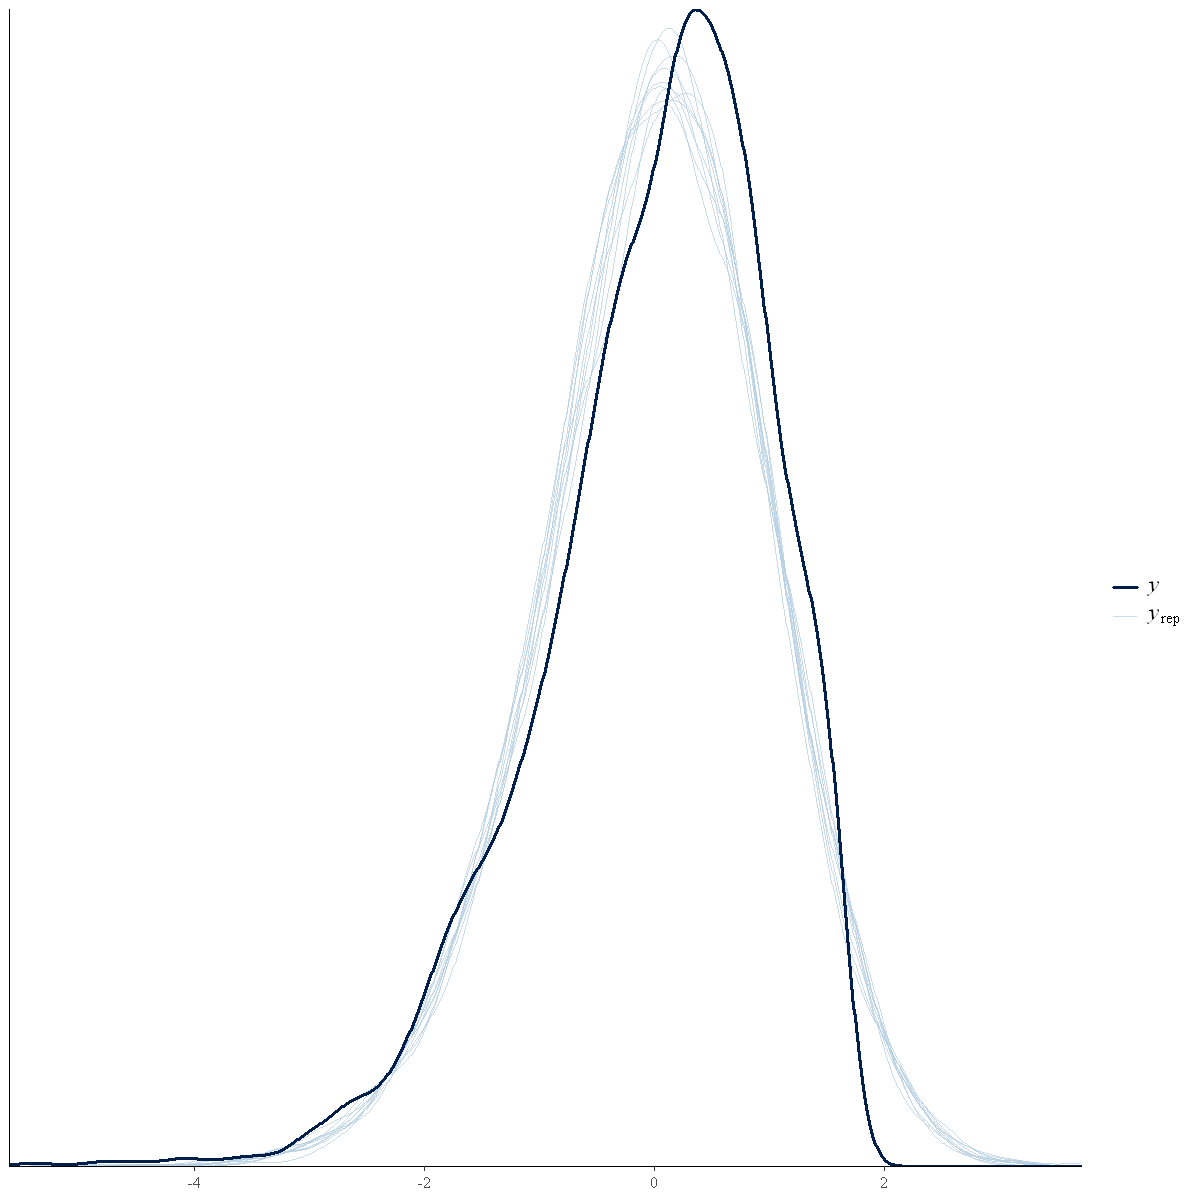

Using 10 posterior draws for ppc type 'dens_overlay' by default.



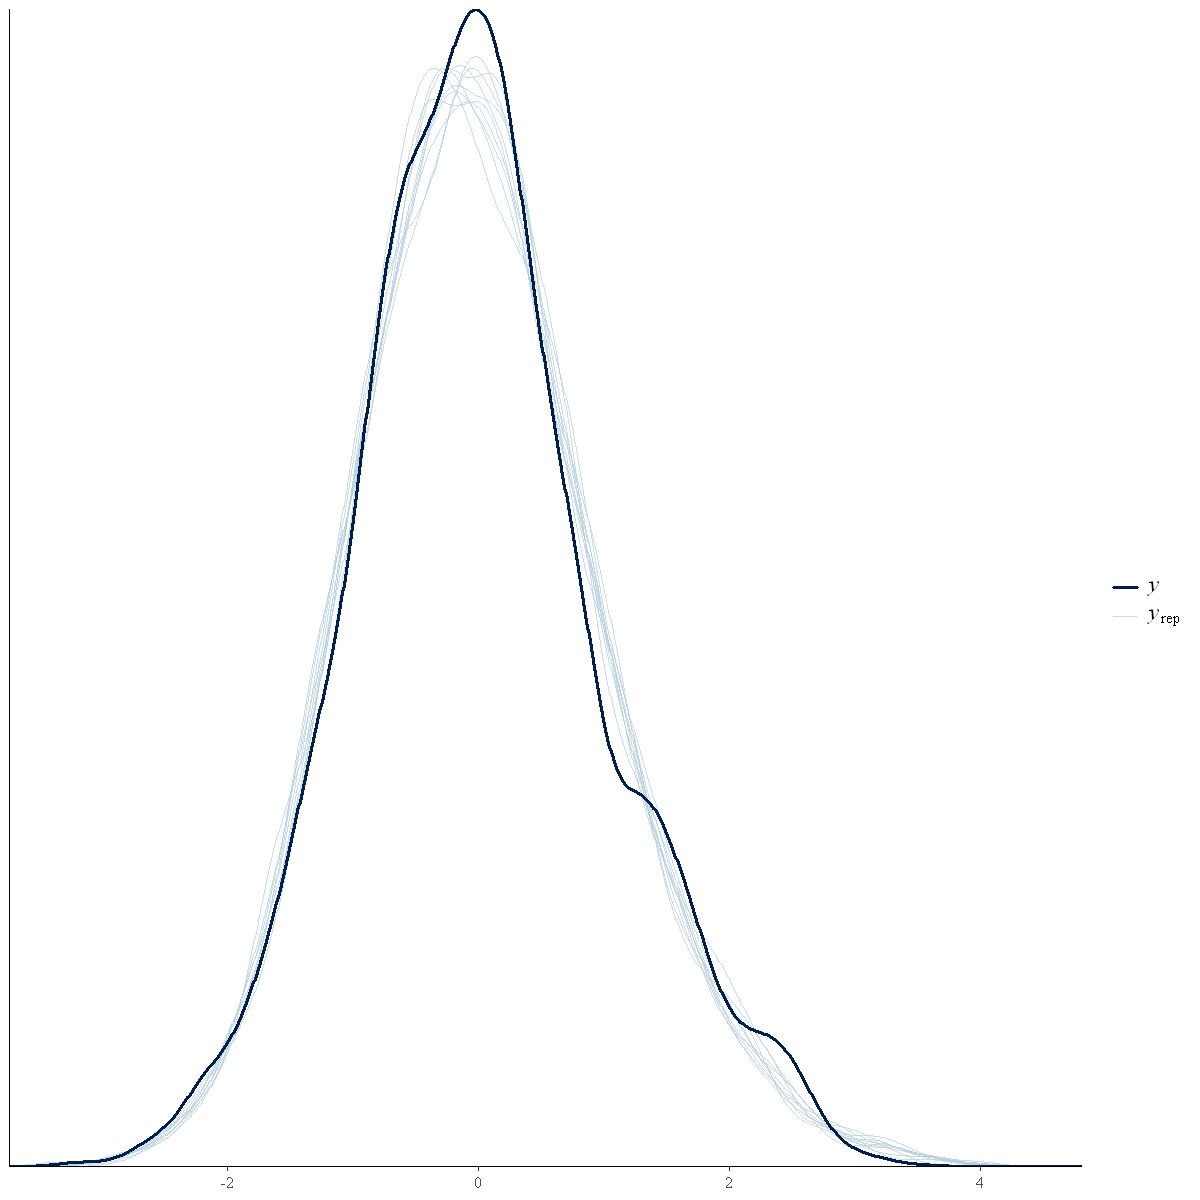

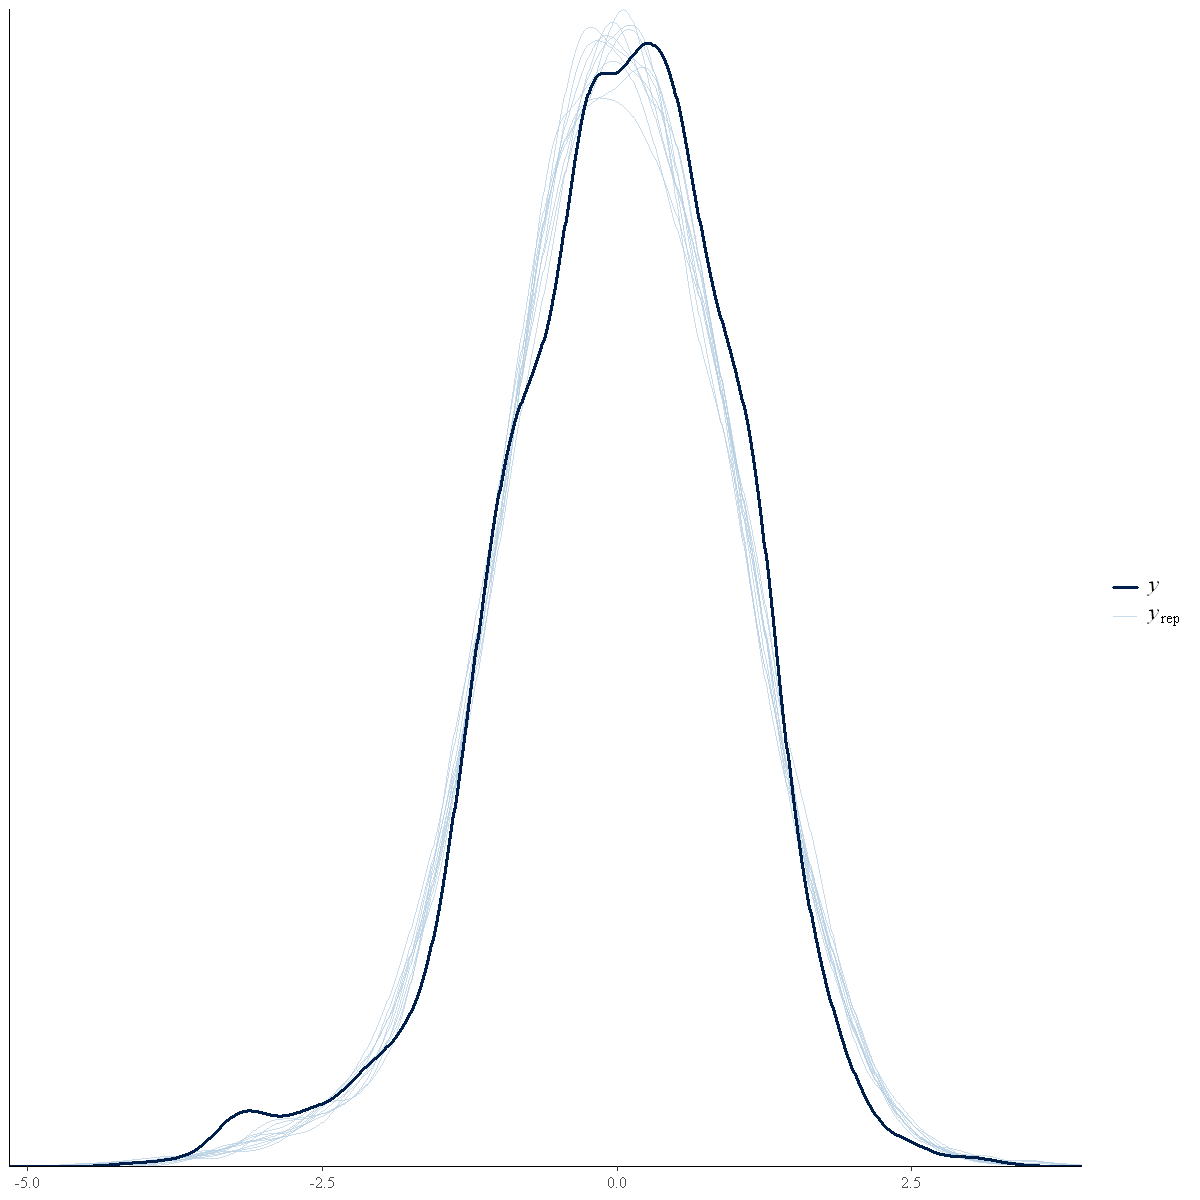

In [24]:
brms::pp_check(simple_brms, resp = "F00679")
brms::pp_check(simple_brms, resp = "F00727")
brms::pp_check(simple_brms, resp = "F00709")

In [25]:
brms::bayes_R2(simple_brms)

,Estimate,Est.Error,Q2.5,Q97.5
R2F00727,0.5816111,0.007367682,0.5668227,0.5957569
R2F00679,0.5202478,0.008462541,0.5034430,0.5365182
R2F00709,0.6504315,0.006047578,0.6383653,0.6620862


In [ ]:
brms::loo(simple_brms, phylo_brms)